# Random Polynomial: the campaign scan, end to end

An MLP on a random polynomial regression target (the *true* polynomial task, C-D1 -- the pre-campaign runs used a different target, so legacy losses are not comparable, only ranks are).

**What this notebook reports.** Every headline number is a **confirmation-seed** number:
`polynomial_scan_confirm/` re-runs the configuration `bench/best_configs.json` selected --- 5 fresh
model seeds and 3 data seeds (3 different random problems)
--- and the tuning-seed numbers stand beside it so the selection optimism is visible rather
than removed.  Selection is the seed-mean final **validation** loss under the binding rule
(eligible -> fewest diverged -> seed mean); the test loss and accuracy are **outcomes** of
that choice and never select anything.  A diverged run has no value, is left out of every
mean and is **counted**: every table carries `finished / attempted` from the pass's
manifest.  A shaded band or a `±` is 1 std (ddof = 1) over seeds, never a confidence
interval.

**Where the numbers come from.** `analysis/headline.py` is the one implementation of the
confirmation table, the paired differences, the tuning-budget curves, the efficiency and
time-to-target tables; this notebook drives it through `analysis/headline_figs.py` and
never re-derives one of those numbers by hand.  Wall times come from `polynomial_scan_timing/`
only --- one configuration at a time, alone on a GPU --- because the scan's own and the
confirmation pass's wall clocks are inflated by shard co-tenancy.

**Not in this notebook.** The singular-value spectra and the mechanism figures (they read
`polynomial_scan_diag/` and the checkpoint spectra) --- see section 10.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import budget
import headline as hl
import headline_figs as hf
import paired
import scan_analysis as sa
import style
from style import set_style, DATASET_TITLES

set_style()
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 80)

In [2]:
SCAN      = 'polynomial_scan'
TITLE     = DATASET_TITLES['polynomial']
PLOT_DIR  = 'plots_v2/polynomial'

# Model selection: the seed-mean final VALIDATION loss, everywhere, for every method.
METRIC = 'final_val_loss'

# The learning rate the Sven k / rtol slices zoom in on.
FOCUS_LR = 0.5

# Every method the scan contains is reported; `BASELINES` only fixes the plot ORDER for
# the helpers that take one.  AdamW / MuonW are Adam / Muon at their own default weight
# decay; SGDm is SGD at momentum 0.9; `LBFGS` is torch.optim.LBFGS on MINIBATCHES and
# displays as "Stochastic L-BFGS" (style.method_label, C-B7).
BASELINES = ['SGD', 'SGDm', 'PolyakSGD', 'RMSprop', 'Adam', 'AdamW', 'LBFGS',
             'Muon', 'MuonW', 'SOAP', 'Shampoo', 'KFAC', 'HIG', 'JD_UPGrad']

In [3]:
scan = sa.load_scan(SCAN, TITLE, PLOT_DIR, metric=METRIC)
BASELINES = [b for b in BASELINES if b in scan.baselines]
print(f'plots -> {scan.plot_dir.resolve()}  (PDF + PNG)')
print(f'methods in the scan: Sven + {BASELINES}')

# The standalone (NPROC=1) timing pass, joined by run_id.  It also CHECKS that the
# standalone runs reproduced the scan's trajectories: the scans ran mostly on A100-40GB
# MIG slices and the passes on full A100-80GB, and Muon (bf16 Newton-Schulz), L-BFGS,
# SOAP/Shampoo/HIG and every CIFAR run are not bit-reproducible across GPU types.  The
# deviation printed below is the evidence, not an assumption -- see section 6.
timing = sa.attach_standalone_times(scan)

Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
polynomial_scan: 1630 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1]
  260 diverged run(s), excluded from seed means: {'LBFGS': 204, 'KFAC': 21, 'SGDm': 12, 'SGD': 8, 'SOAP': 4, 'SVD': 4, 'HIG': 3, 'RMSprop': 3, 'MuonW': 1}
  manifest: 1630 of 1630 intended runs present, 0 with no record
plots -> /n/home11/sambt/iaifi/sv3/analysis/plots_v2/polynomial  (PDF + PNG)
methods in the scan: Sven + ['SGD', 'SGDm', 'PolyakSGD', 'RMSprop', 'Adam', 'AdamW', 'LBFGS', 'Muon', 'MuonW', 'SOAP', 'Shampoo', 'KFAC', 'HIG', 'JD_UPGrad']
Loaded 75 runs from ../experiment_results/_cache/polynomial_scan_timing.slim.pkl (slim cache)


[standalone] 75 runs in polynomial_scan_timing/, 75 joined; final-val-loss deviation vs scan: max 2.53e-01, median 8.68e-09


## 2. Results summary --- the confirmation seeds, with the tuning seeds beside them

One row per method: the configuration `bench/best_configs.json` selected, its
confirmation-seed final validation loss (what selected it), the final **test** loss and
accuracy and the eval-mode train loss (outcomes), `finished / attempted`, and the tuning
numbers with the gap.  The gap to quote as *selection optimism* is the **tuning-instance** one: the pooled column also carries two random problems the tuning never saw.

In [4]:
# Is the selection of record still the selection of what is on disk?  A tuning-grid
# record newer than bench/best_configs.json, or a live claim with no record yet, means
# the scan is still moving and every table below is PROVISIONAL.
provisional = hf.provisional_banner(SCAN)
conf, view = hf.summary_cell(SCAN)

[fresh] polynomial_scan: no runs in flight; every table below is final with respect to the selection written 2026-09-20T03:58:14-0400
Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
Loaded 225 runs from ../experiment_results/_cache/polynomial_scan_confirm.slim.pkl (slim cache)



### Random Polynomial (polynomial_scan) -- selected configuration of every method on the CONFIRMATION seeds, tuning seeds beside it; $\pm$ 1 std over seeds
| method | config | val (confirm) | test (confirm) | train (eval mode) | finished/attempted | val (tuning) | tuning fin/att | val, mean +/- between-instance | val, within-instance seed std | val, tuning instance | gap, tuning instance | gap rel, tuning instance (optimism) | gap rel, pooled (+2 unseen instances) |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| HIG | lr=0.1, tau=1e-08 | 0.08406 ± 0.02407 | 0.08028 ± 0.02047 | 0.05783 ± 0.01371 | 15/15 | 0.07149 ± 0.006645 | 5/5 | 0.08406 ± 0.02679 | 0.008164 | 0.07169 | +0.0001982 | +0.3% | +17.6% |
| Sven | k=16, lr=0.5, rtol=0.03 | 0.1388 ± 0.05508 | 0.136 ± 0.05542 | 0.1106 ± 0.04222 | 15/15 | 0.1095 ± 0.007301 | 5/5 | 0.1388 ± 0.05704 | 0.02594 | 0.1102 | +0.0006972 | +0.6% | +26.8% |
| JD (UPGrad) | lr=0.001, aggregator=UPGrad, inner_optimizer=Adam | 0.1635 ± 0.0493

In [5]:
rank = hf.ranking_line(SCAN)

Sven on Random Polynomial, confirmation seeds: 2/15 on validation loss, 2/15 on test loss
  best method by validation loss: HIG (0.08406) vs Sven 0.1388


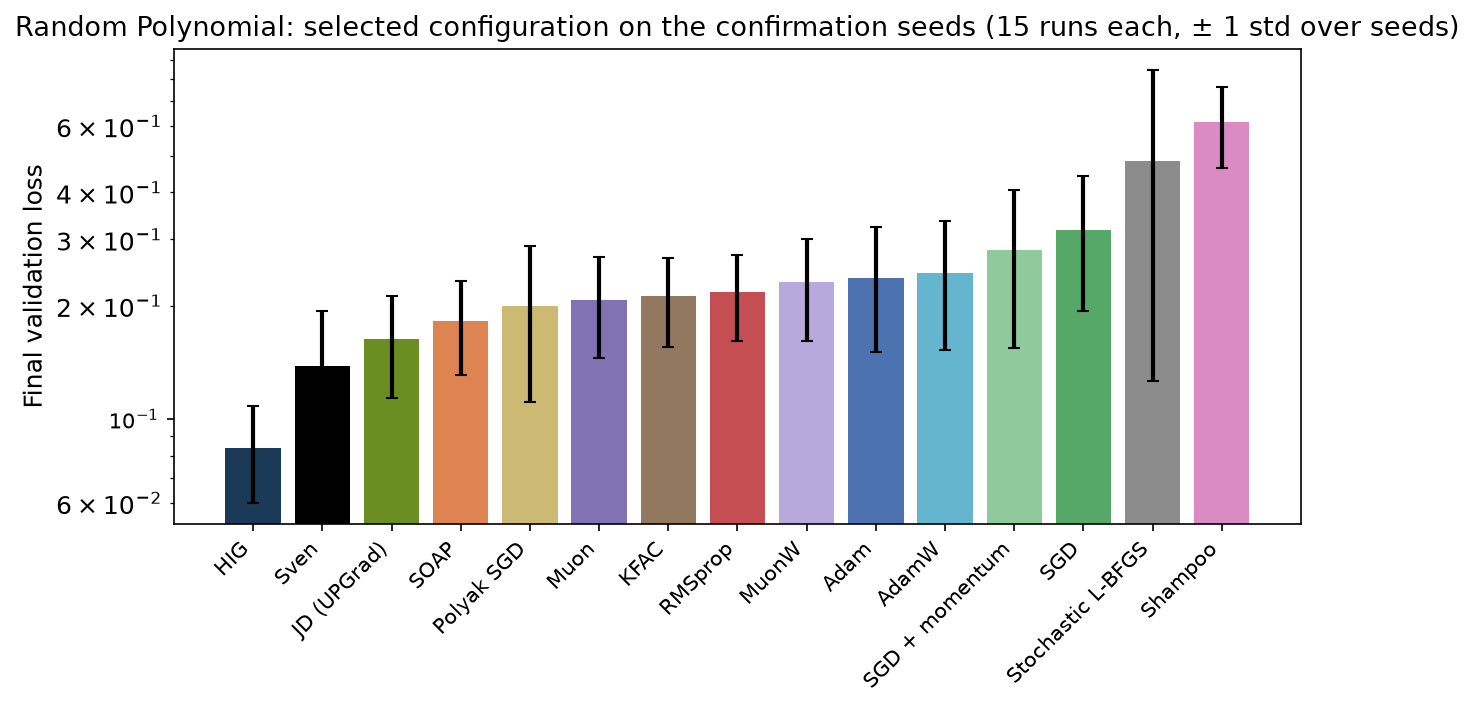

In [6]:
# The same table as a figure: confirmation-seed final validation loss per method.
fig, ax = plt.subplots(figsize=(9, 5))
d = conf.sort_values('val_conf', kind='mergesort')
x = np.arange(len(d))
mean = d['val_conf'].to_numpy(float)
std = np.nan_to_num(d['val_conf_std'].to_numpy(float))
ax.bar(x, mean, yerr=[np.minimum(std, mean * 0.999), std], capsize=3,
       color=[style.method_color(m) for m in d['method']])
ax.set_xticks(x)
ax.set_xticklabels([style.method_label(m) for m in d['method']], rotation=45, ha='right')
ax.set_yscale('log')
ax.set_ylabel('Final validation loss')
ax.set_title(f'{TITLE}: selected configuration on the confirmation seeds '
             f'({int(conf["fin_conf"].max())} runs each, {style.seed_spread_label(plain=True)})',
             fontsize=13)
ax.tick_params(labelsize=10)
ax.yaxis.label.set_size(12)
fig.tight_layout()
hf.save(fig, scan, 'confirm_best_per_method')
plt.show()

## 3. Convergence: every method, on three x-axes

The same confirmation runs on the three axes that a cost claim can be made in
(F21 / C-A5), because a method can win on one and lose on another:

* **optimizer steps** --- how many updates it took;
* **examples processed** --- steps x batch size, the data-cost axis (every optimizer runs
  with `drop_last=True`, so this is examples actually stepped on, not `n_train`);
* **synchronised training time** --- the cumulative per-epoch `train_times` of the
  **standalone** timing pass, i.e. GPU-synchronised training time with evaluation (a
  large, identical overhead for every method) taken out.  The scan's own wall clock is
  never used for this.

The top row is the front of the field --- the best six by confirmation validation loss,
plus Sven --- and the bottom row is *every* method with a selected configuration, so the
choice of six hides nothing.  Sven is black and thick throughout.

Loaded 75 runs from ../experiment_results/_cache/polynomial_scan_timing.slim.pkl (slim cache)
15 methods, 225 confirmation runs; time axis available for 15 of them


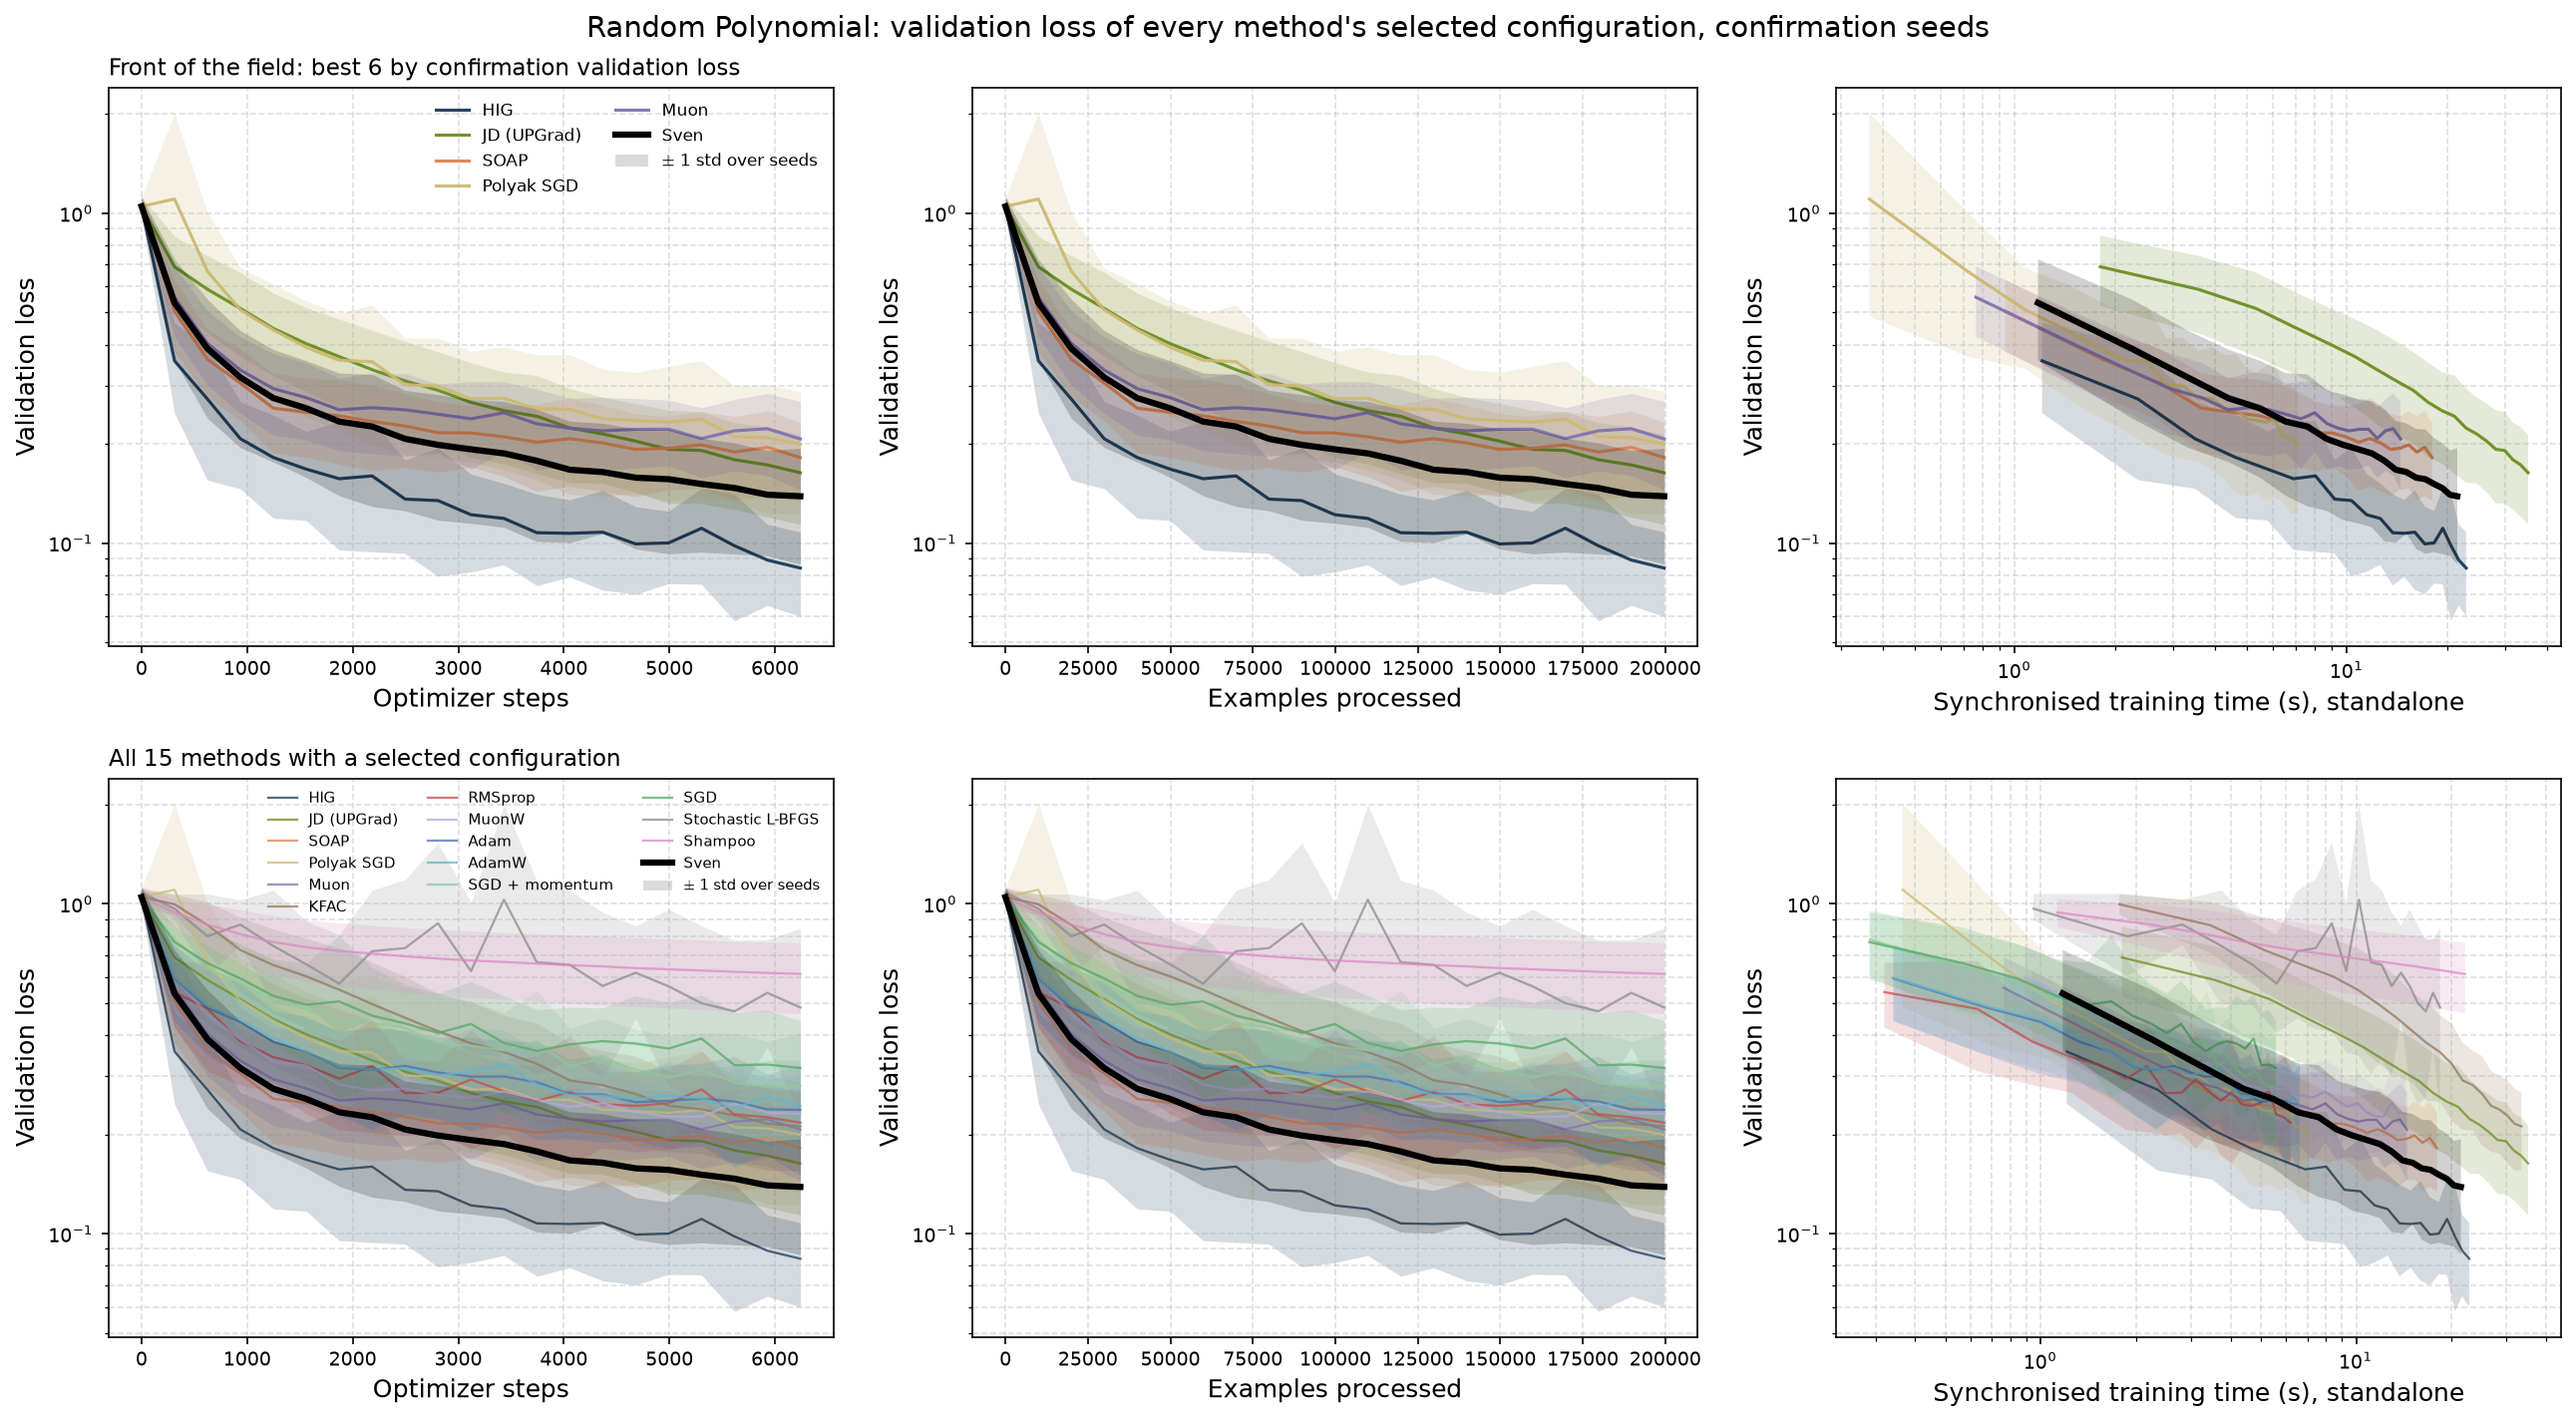

In [7]:
runs  = hf.confirm_runs(SCAN)          # {method: the confirmation runs of its selected config}
times = hf.standalone_epoch_times(SCAN)   # {method: per-epoch synchronised train time}
order = hf.method_ranking(SCAN, table=conf)
print(f'{len(runs)} methods, {sum(len(r) for r in runs.values())} confirmation runs; '
      f'time axis available for {len(times)} of them')

fig, axes, info = hf.curve_figure(SCAN, which='val', runs=runs, times=times, order=order)
fig.suptitle(f'{TITLE}: validation loss of every method\'s selected configuration, '
             f'confirmation seeds', y=1.005, fontsize=14)
hf.save(fig, scan, 'confirm_val_curves_three_axes')
plt.show()

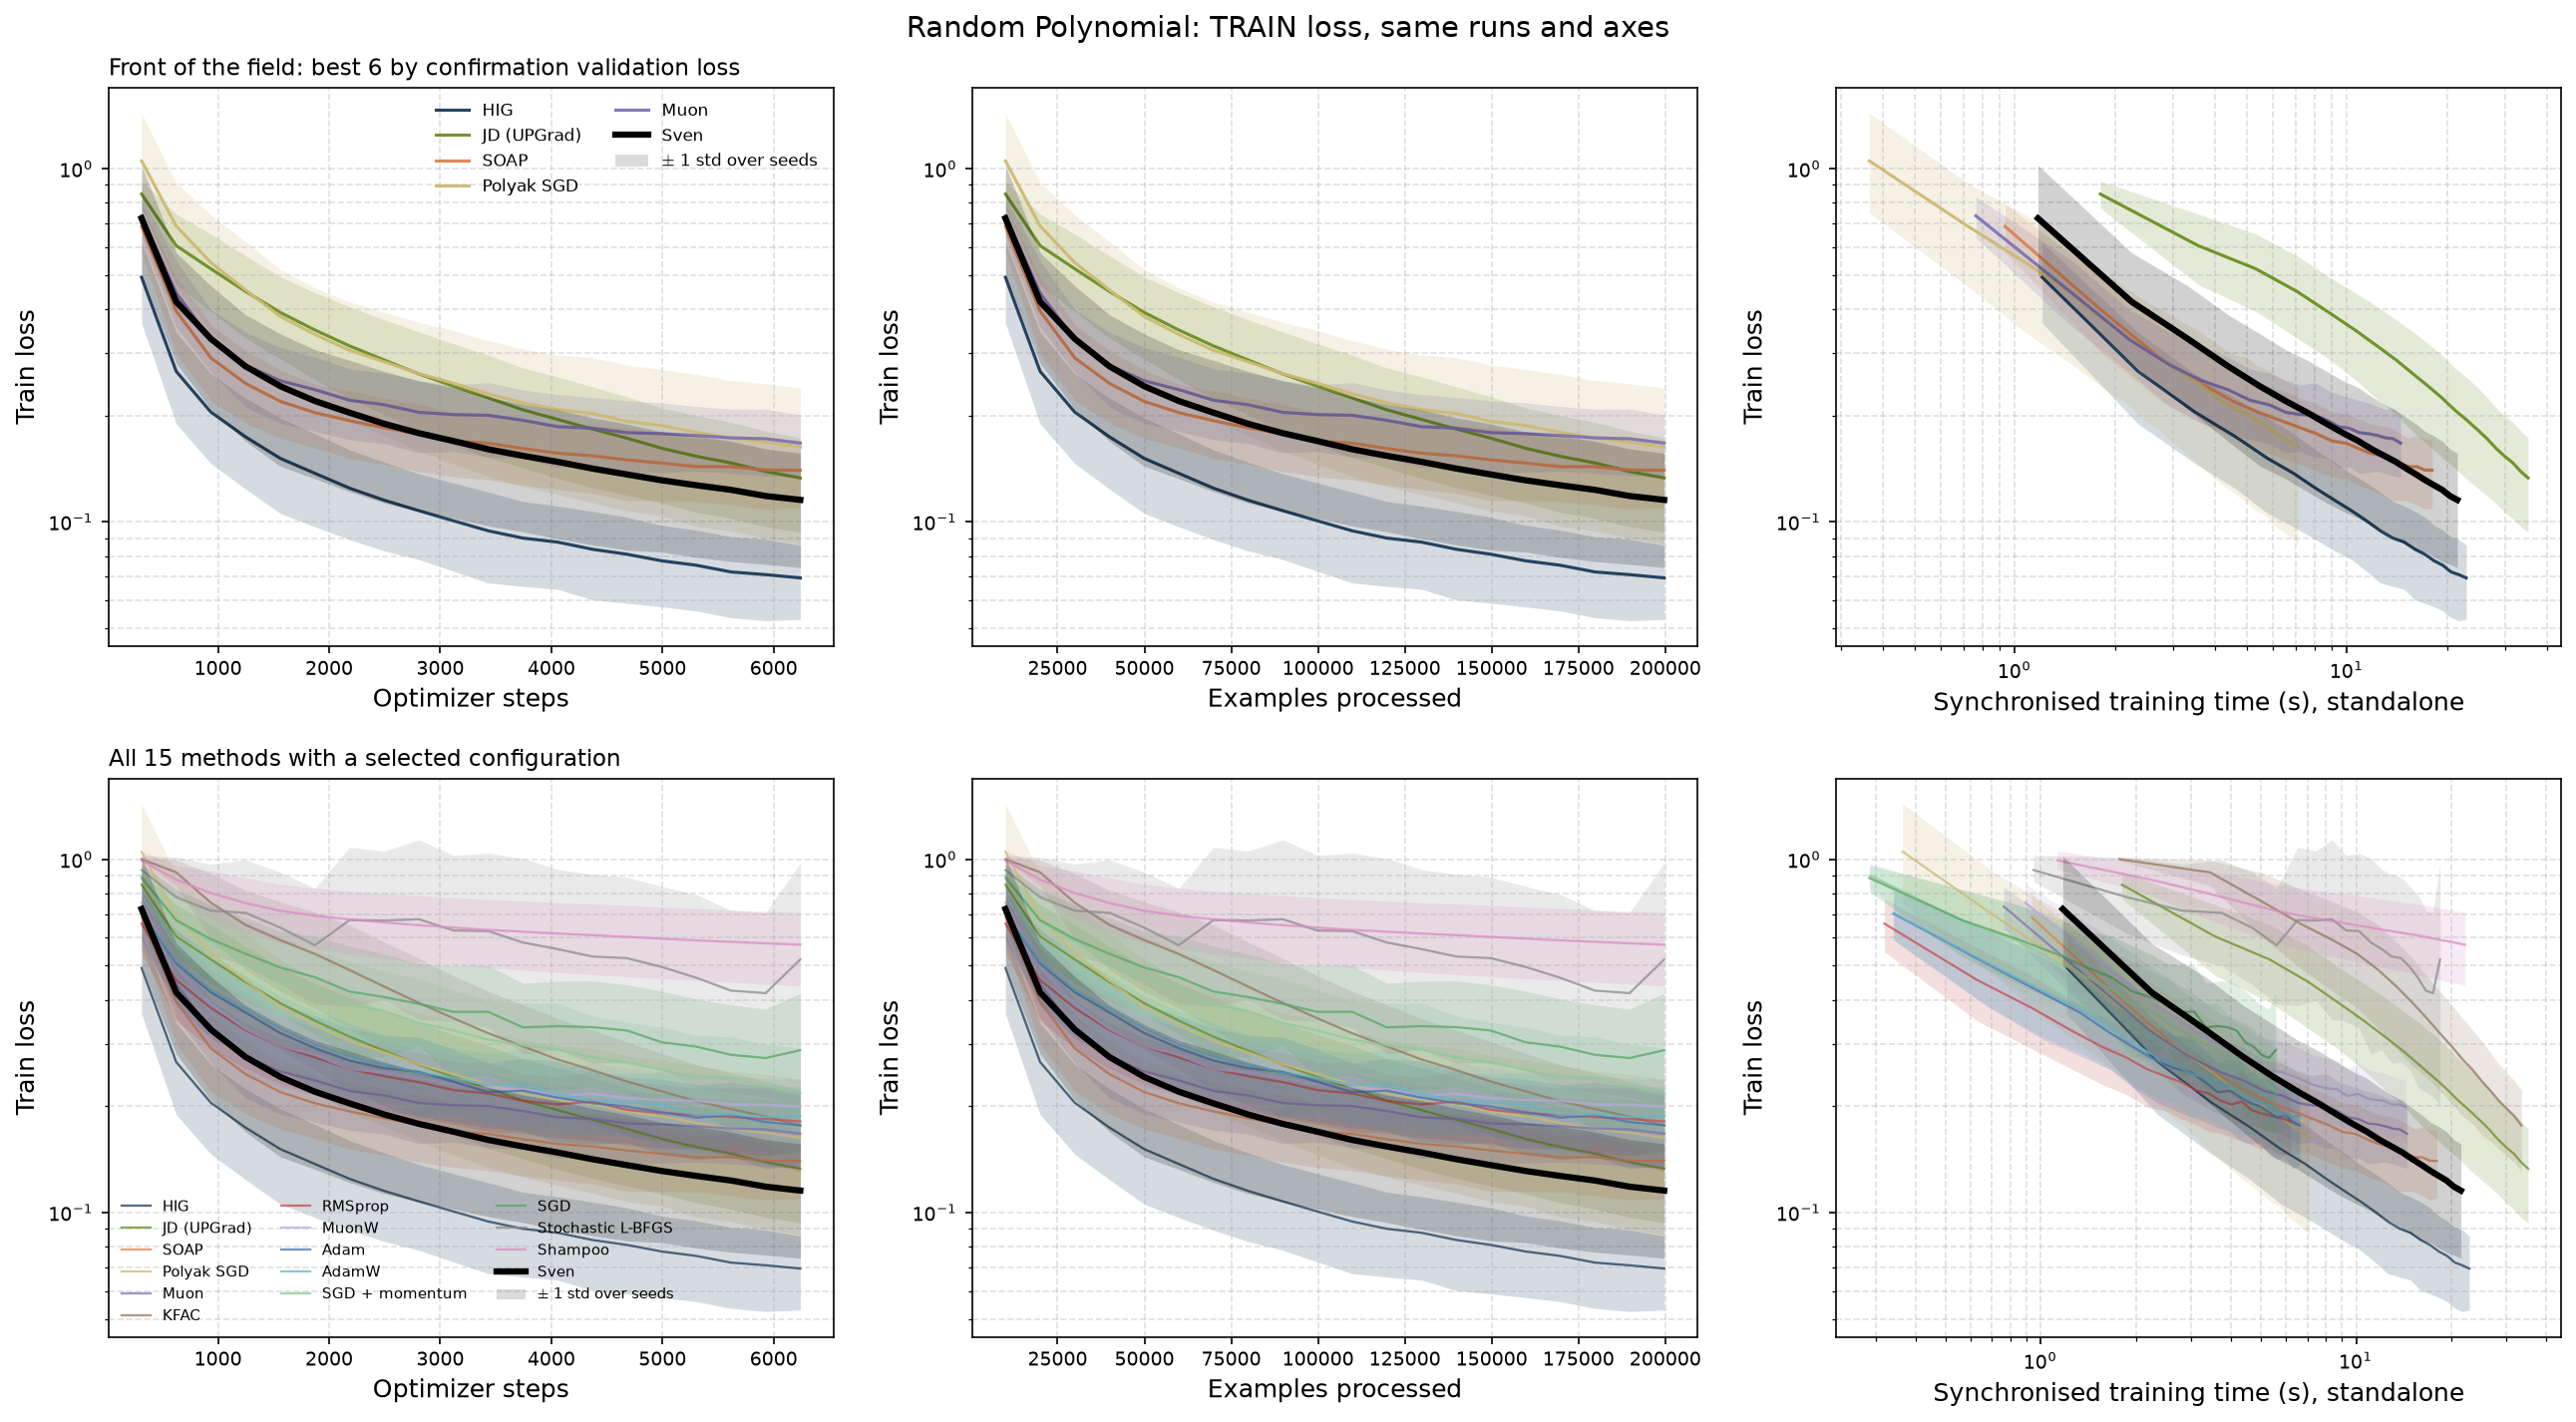

no accuracy on this task (regression): the loss is the whole outcome


In [8]:
fig, axes, info_tr = hf.curve_figure(SCAN, which='train', runs=runs, times=times, order=order)
fig.suptitle(f'{TITLE}: TRAIN loss, same runs and axes', y=1.005, fontsize=14)
hf.save(fig, scan, 'confirm_train_curves_three_axes')
plt.show()

if scan.has_acc:
    fig, axes, info_acc = hf.curve_figure(SCAN, which='val_acc', runs=runs, times=times,
                                          order=order)
    fig.suptitle(f'{TITLE}: validation ACCURACY (an outcome, never selected on)',
                 y=1.005, fontsize=14)
    hf.save(fig, scan, 'confirm_val_acc_curves_three_axes')
    plt.show()
else:
    print('no accuracy on this task (regression): the loss is the whole outcome')

### The effect of $k$ on Sven's own trajectory

Loss curves across the truncation rank $k$ at a fixed $(\eta, \mathrm{rtol})$, with the
best SGD run for scale.  This is the tuning scan (all $k$ values were only run there),
seed-averaged with the usual band.

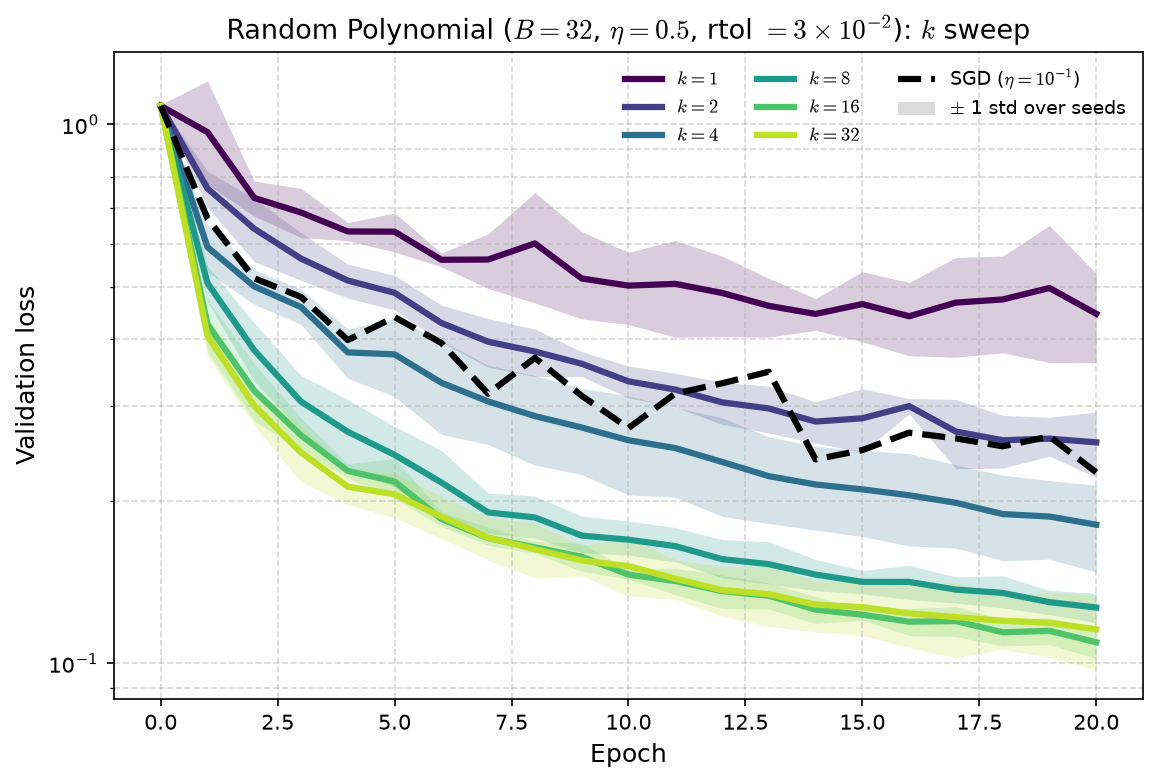

In [9]:
sel_sven, sven_entry = hf.selected_sven(SCAN)
for rtol in [sel_sven['rtol']]:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    drawn = sa.plot_k_sweep(scan, ax, lr=FOCUS_LR, rtol=rtol, which='val')
    if not drawn:
        plt.close(fig)
        print(f'  no Sven runs at lr={FOCUS_LR}, rtol={rtol}')
        continue
    ax.set_title(f'{TITLE} ($B = {scan.B}$, $\\eta = {sa.fmt(FOCUS_LR)}$, '
                 f'rtol $= {sa.fmt(rtol)}$): $k$ sweep', fontsize=13)
    ax.grid(which='both', ls='--', alpha=0.5)
    ax.legend(ncol=3, fontsize=9)
    ax.tick_params(labelsize=10); ax.xaxis.label.set_size(12); ax.yaxis.label.set_size(12)
    fig.tight_layout()
    hf.save(fig, scan, f'val_loss_k_sweep_lr{FOCUS_LR:g}_rtol{rtol:g}')
    plt.show()

## 4. Paired differences against Sven

The difference is taken **within a pair** --- the same model seed, hence the same
initialisation and data order (and the same problem instance where there are several) ---
which removes the seed-to-seed variation that dominates the unpaired spread.  The interval
is a Student-*t* interval on the **mean difference**, not the seed band.

`mean = Sven − other`, so for a **loss** negative means Sven is better, and for an
**accuracy** positive does; `sven_better` counts the pairs Sven won under the metric's own
direction.  `significant` means only "this interval excludes zero": with 5 (or 15) pairs
and no correction for the 13--14 comparisons per scan it is a reading aid, not a test.


### Random Polynomial -- paired Sven − method, final validation loss, 95% $t$-interval on the mean; pairs on model_seed x data_seed
| display | n | mean | half_width | ci_low | ci_high | n_unpaired | sven_better | significant |
|---|---|---|---|---|---|---|---|---|
| Shampoo | 15 | -0.4749 | 0.06133 | -0.5362 | -0.4135 | 0 | 15 | True |
| Stochastic L-BFGS | 2 | -0.3348 | 2.607 | -2.942 | 2.273 | 13 | 2 | False |
| SGD | 15 | -0.1795 | 0.04556 | -0.225 | -0.1339 | 0 | 15 | True |
| SGD + momentum | 15 | -0.1417 | 0.04365 | -0.1853 | -0.09805 | 0 | 15 | True |
| AdamW | 15 | -0.1054 | 0.04347 | -0.1489 | -0.06198 | 0 | 14 | True |
| Adam | 15 | -0.09886 | 0.03618 | -0.135 | -0.06268 | 0 | 15 | True |
| MuonW | 15 | -0.0925 | 0.0287 | -0.1212 | -0.0638 | 0 | 15 | True |
| RMSprop | 15 | -0.07849 | 0.01437 | -0.09285 | -0.06412 | 0 | 15 | True |
| KFAC | 15 | -0.07303 | 0.01623 | -0.08926 | -0.0568 | 0 | 15 | True |
| Muon | 15 | -0.06817 | 0.02539 | -0.09357 | -0.04278 | 0 | 14 | True |

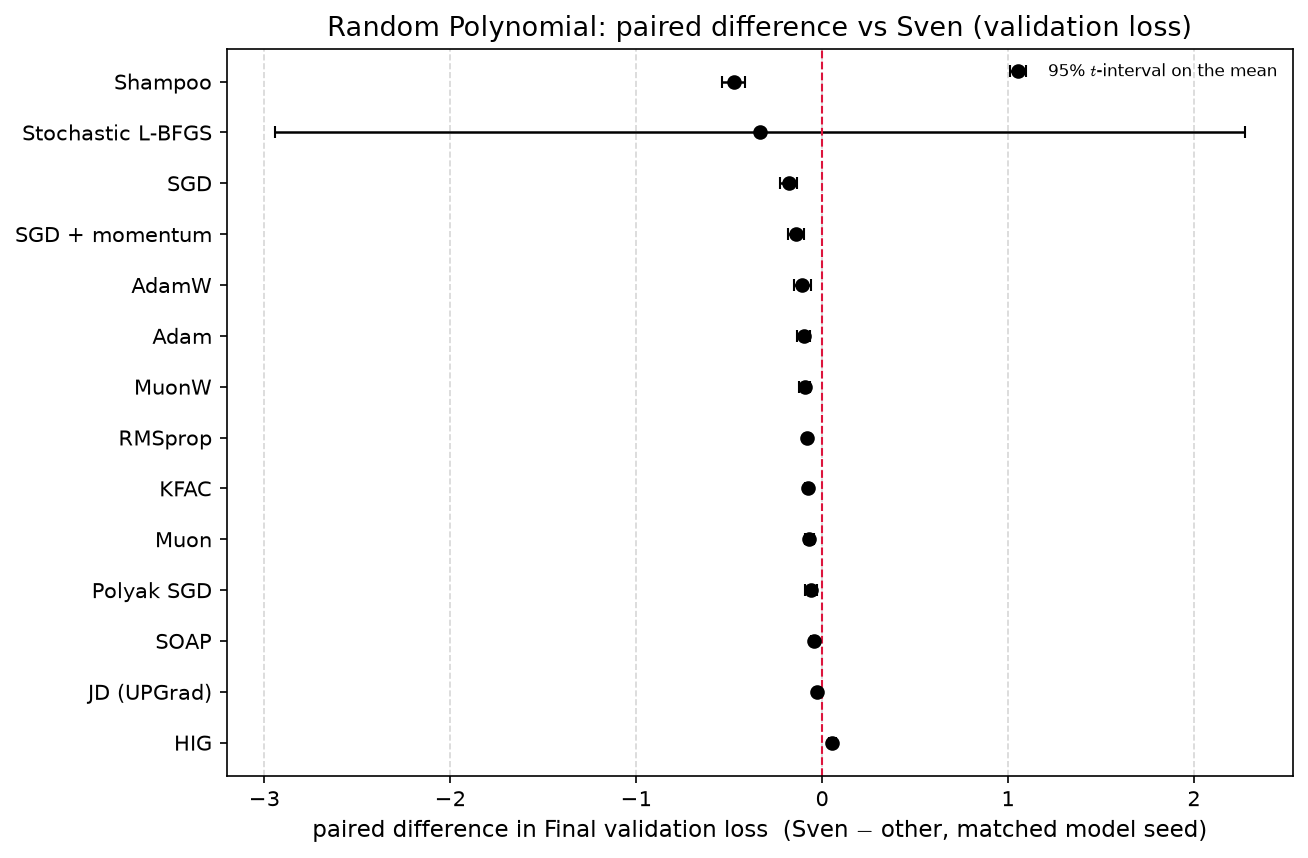

In [10]:
PCOLS = ['display', 'n', 'mean', 'half_width', 'ci_low', 'ci_high', 'n_unpaired',
         'sven_better', 'significant']
pv = hl.paired_vs_sven(SCAN)
hl.print_table(pv[PCOLS], f'{TITLE} -- paired Sven − method, final validation loss, '
                          f'{paired.interval_label(0.95)}; pairs on {pv.attrs["pair_on"]}')
print(f'  sign: {pv.attrs["sign"]}')

fig, ax = plt.subplots(figsize=(9, 6))
paired.plot_paired(pv, ax, label_col='display')
ax.set_title(f'{TITLE}: paired difference vs Sven (validation loss)', fontsize=13)
ax.tick_params(labelsize=10); ax.xaxis.label.set_size(11)
fig.tight_layout()
hf.save(fig, scan, 'paired_vs_sven_val')
plt.show()

In [11]:
# The same paired difference on the test OUTCOMES.  paired.py refuses a test metric by
# design (it is the module every selection goes through), so these go through
# headline.paired_outcome_vs_sven, which repeats the arithmetic for a quantity that may
# not select anything.
outs = {}
for metric in ('final_test_loss', 'final_test_acc'):
    t = hl.paired_outcome_vs_sven(SCAN, metric=metric)
    if t.empty:
        continue
    outs[metric] = t
    hl.print_table(t[PCOLS], f'{TITLE} -- paired Sven − method, {metric} (OUTCOME) -- '
                             + ('larger is better' if t.attrs['higher_is_better']
                                else 'a loss: lower is better'))
    print(f'  sign: {t.attrs["sign"]}')


### Random Polynomial -- paired Sven − method, final_test_loss (OUTCOME) -- a loss: lower is better
| display | n | mean | half_width | ci_low | ci_high | n_unpaired | sven_better | significant |
|---|---|---|---|---|---|---|---|---|
| Shampoo | 15 | -0.4704 | 0.05587 | -0.5262 | -0.4145 | 0 | 15 | True |
| Stochastic L-BFGS | 2 | -0.3141 | 2.391 | -2.705 | 2.077 | 13 | 2 | False |
| SGD | 15 | -0.179 | 0.04693 | -0.2259 | -0.132 | 0 | 15 | True |
| SGD + momentum | 15 | -0.1363 | 0.03635 | -0.1726 | -0.09994 | 0 | 15 | True |
| AdamW | 15 | -0.1043 | 0.04617 | -0.1504 | -0.05809 | 0 | 14 | True |
| Adam | 15 | -0.09229 | 0.034 | -0.1263 | -0.05828 | 0 | 14 | True |
| MuonW | 15 | -0.08655 | 0.02514 | -0.1117 | -0.0614 | 0 | 14 | True |
| RMSprop | 15 | -0.07481 | 0.01782 | -0.09263 | -0.05699 | 0 | 14 | True |
| Muon | 15 | -0.06602 | 0.02484 | -0.09086 | -0.04119 | 0 | 14 | True |
| KFAC | 15 | -0.06529 | 0.01683 | -0.08212 | -0.04846 | 0 | 15 | True |
| Polyak SGD | 15 | -0.05636 |

## 5. Tuning budget: is Sven just better searched?

Sven's grid has 100--180 points against four to nine learning rates for most baselines, so
the obvious objection is that its advantage is search effort.  Two numbers answer it
without a new run.

* **Distinct trajectories.** A Sven grid point whose rtol-rank never reaches $k$ truncates
  nothing extra and is the *identical* trajectory, so counting distinct final validation
  losses within a `(seed, lr)` group measures the search actually performed.
  `distinct_frac` is the fraction of the grid that bought anything.
* **Best-of-$n$.** The exact expected best seed-mean validation loss when $n$
  configurations are drawn at random from a method's grid (order statistics of the finite
  population --- no resampling noise).  Reading every method's curve at the **same $n$** is
  the equal-budget comparison.  A configuration no seed finished is scored at the worst
  seed mean in the scan, because a random search would still have spent a trial on it.

The two numbers do not point the same way, and the section answers its own question with
the second, not the first.  `distinct_frac` says a large part of Sven's grid is redundant
--- which is a point *for* the objection, not against it: the extra points bought less than
their count suggests.  The equal-budget table below is the answer: at `hf.BUDGET_EQUAL_N`
draws it prints where Sven ranks against the whole field when every method is given the
same number of trials (a method whose grid is smaller than $n$ is read at its own grid
size, i.e. having exhausted it).

In [12]:
BCOLS = ['label', 'n_runs', 'n_seeds', 'n_diverged', 'grid_points', 'grid_per_group',
         'distinct_per_group', 'distinct', 'distinct_frac']
bt = hl.budget_table(SCAN)
hl.print_table(bt[BCOLS], f'{TITLE} -- grid points vs DISTINCT trajectories '
                          f'(within {bt.attrs["within"]})')


### Random Polynomial -- grid points vs DISTINCT trajectories (within ('lr',))
| label | n_runs | n_seeds | n_diverged | grid_points | grid_per_group | distinct_per_group | distinct | distinct_frac |
|---|---|---|---|---|---|---|---|---|
| Sven | 720 | 5 | 4 | 144 | 36 | 22.25 | 89 | 0.6181 |
| Stochastic L-BFGS | 225 | 5 | 204 | 45 | 9 | 8.72 | 43.6 | 0.9689 |
| HIG | 150 | 5 | 3 | 30 | 6 | 4.36 | 21.8 | 0.7267 |
| MuonW | 50 | 5 | 1 | 10 | 1 | 1 | 10 | 1 |
| KFAC | 50 | 5 | 21 | 10 | 1 | 1 | 10 | 1 |
| AdamW | 50 | 5 | 0 | 10 | 1 | 1 | 10 | 1 |
| Adam | 50 | 5 | 0 | 10 | 1 | 1 | 10 | 1 |
| SOAP | 50 | 5 | 4 | 10 | 1 | 1 | 10 | 1 |
| Muon | 50 | 5 | 0 | 10 | 1 | 1 | 10 | 1 |
| RMSprop | 50 | 5 | 3 | 10 | 1 | 1 | 10 | 1 |
| SGD | 50 | 5 | 8 | 10 | 1 | 1 | 10 | 1 |
| Shampoo | 50 | 5 | 0 | 10 | 1 | 1 | 10 | 1 |
| SGD + momentum | 50 | 5 | 12 | 10 | 1 | 1 | 10 | 1 |
| JD (UPGrad) | 30 | 5 | 0 | 6 | 1 | 1 | 6 | 1 |
| Polyak SGD | 5 | 5 | 0 | 1 | 1 | 1 | 1 | 1 |


,label,n_runs,n_seeds,n_diverged,grid_points,grid_per_group,distinct_per_group,distinct,distinct_frac
0,Sven,720,5,4,144,36.0,22.25,89.0,0.618056
1,Stochastic L-BFGS,225,5,204,45,9.0,8.72,43.6,0.968889
2,HIG,150,5,3,30,6.0,4.36,21.8,0.726667
3,MuonW,50,5,1,10,1.0,1.00,10.0,1.000000
4,KFAC,50,5,21,10,1.0,1.00,10.0,1.000000
5,AdamW,50,5,0,10,1.0,1.00,10.0,1.000000
6,Adam,50,5,0,10,1.0,1.00,10.0,1.000000
7,SOAP,50,5,4,10,1.0,1.00,10.0,1.000000
8,Muon,50,5,0,10,1.0,1.00,10.0,1.000000
9,RMSprop,50,5,3,10,1.0,1.00,10.0,1.000000



### Random Polynomial -- expected best seed-mean validation loss at budget n (a never-finished config scored 5.71)
| method | grid_points | 1 | 2 | 4 | 8 | 16 | 32 | 64 | 128 |
|---|---|---|---|---|---|---|---|---|---|
| Sven | 144 | 0.4947 | 0.2833 | 0.2031 | 0.1581 | 0.1345 | 0.1222 | 0.1148 | 0.1102 |
| Stochastic L-BFGS | 45 | 4.37 | 3.332 | 1.926 | 0.6676 | 0.2031 | 0.169 |  |  |
| HIG | 30 | 0.325 | 0.1441 | 0.08767 | 0.07575 | 0.07212 |  |  |  |
| AdamW | 10 | 0.8321 | 0.6409 | 0.4004 | 0.2169 |  |  |  |  |
| KFAC | 10 | 2.196 | 0.8579 | 0.2747 | 0.1791 |  |  |  |  |
| Muon | 10 | 0.8736 | 0.6958 | 0.4315 | 0.183 |  |  |  |  |
| Adam | 10 | 0.8416 | 0.6489 | 0.3957 | 0.2001 |  |  |  |  |
| SOAP | 10 | 0.8689 | 0.6755 | 0.4043 | 0.1644 |  |  |  |  |
| MuonW | 10 | 0.8994 | 0.6944 | 0.4474 | 0.2223 |  |  |  |  |
| SGD | 10 | 1.328 | 0.6912 | 0.4509 | 0.2564 |  |  |  |  |
| RMSprop | 10 | 0.9068 | 0.673 | 0.4072 | 0.2018 |  |  |  |  |
| Shampoo | 10 | 0.9315 | 0.8192 | 0.6769 | 0.

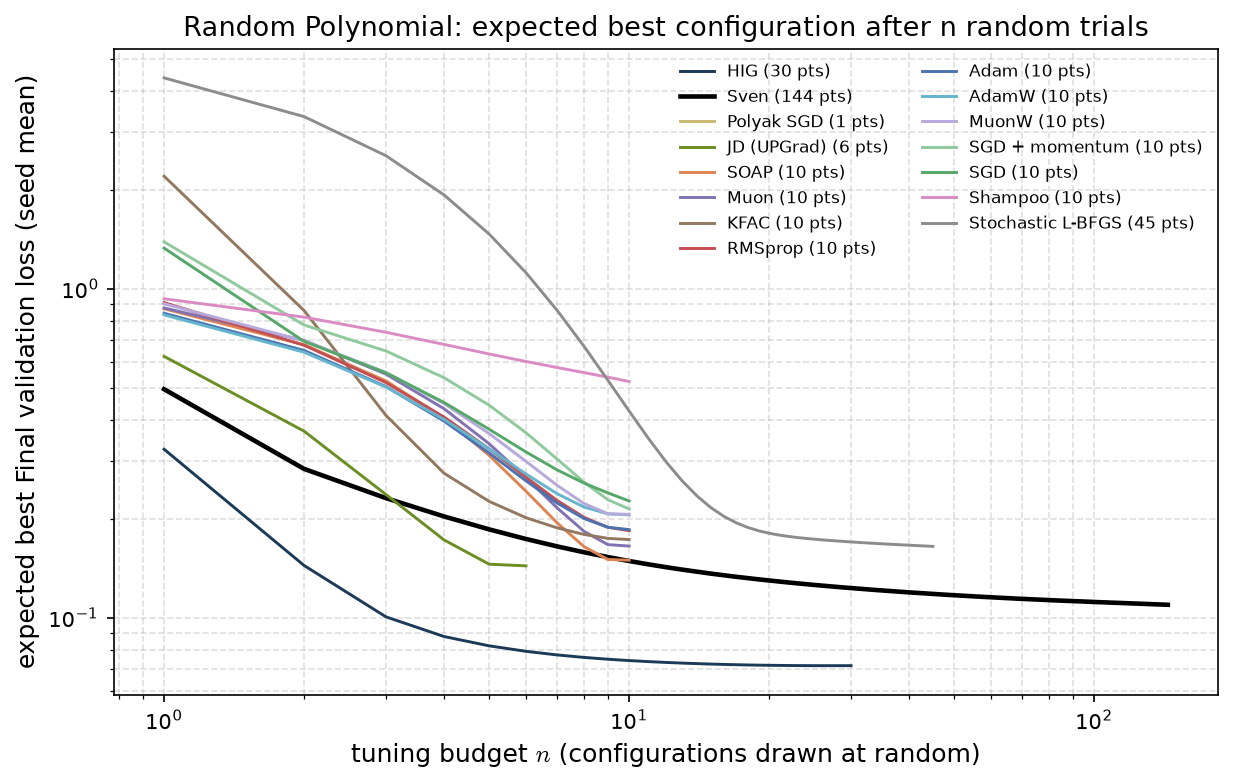

In [13]:
curves, at_n = hl.best_of_n_table(SCAN)
hl.print_table(at_n.reset_index().rename(columns={'index': 'method'}),
               f'{TITLE} -- expected best seed-mean validation loss at budget n '
               f'(a never-finished config scored {at_n.attrs["diverged_value"]:.3g})')

# The equal-budget answer, as an ordering: every method at n = BUDGET_EQUAL_N draws.
eq = hf.equal_budget_table(curves)
hl.print_table(eq, f'{TITLE} -- expected best seed-mean validation loss at an EQUAL '
                   f'budget of n = {eq.attrs["n"]} random trials (best first; `n_used` '
                   f'is the budget actually available to that grid)')
_sv = eq[eq['method'] == 'Sven']
if len(_sv):
    _i = int(_sv.index[0])
    print(f'  at n = {eq.attrs["n"]} Sven is {_i + 1} of {len(eq)}: '
          f'{_i} method(s) reach a lower expected best from the same number of trials')
    _hit = curves[(curves['method'] == 'Sven')
                  & (curves['expected_best'] <= eq['expected_best'].iloc[0])]
    _need = int(_hit['n'].iloc[0]) if len(_hit) else None
    _need_txt = str(_need) if _need else 'never, anywhere on its grid'
    print(f'  budget Sven needs to match {eq["display"].iloc[0]} at n = '
          f'{eq.attrs["n"]}: n = {_need_txt}')

fig, ax = plt.subplots(figsize=(8.5, 5.5))
budget.plot_best_of_n(curves, ax)
hf.relabel_methods(ax, fontsize=8, ncol=2)
ax.set_title(f'{TITLE}: expected best configuration after n random trials', fontsize=13)
ax.tick_params(labelsize=10); ax.xaxis.label.set_size(12); ax.yaxis.label.set_size(12)
fig.tight_layout()
hf.save(fig, scan, 'best_of_n')
plt.show()

## 6. Efficiency, and time to target

**Where the times come from.** `polynomial_scan_timing/` only: the selected configuration, one at a
time, alone on a GPU, with logging off.  `sync_train_s` is the sum of `train_times`
(synchronised training time, evaluation excluded), `ms_per_step` is that divided by the
steps, and `scan_inflation` = scan / standalone is printed with the GPU types of both
passes, because on the MLP scans the two passes did **not** run on the same hardware ---
the scans were mostly on an A100-40GB MIG 3g.20gb slice and every timing run had a full
A100-80GB, so the ratio is co-tenancy *plus* a capability change and is not a clean
"what sharding cost".

**The confirmation pass is not automatically homogeneous either.**  Section 2 prints which
GPU type each method's confirmation runs used: where they are mixed, a rank or a paired
difference in sections 2--4 compares runs from *different* hardware, and the deviation
measured in the table below is the size of that effect.  (Toy, polynomial and both CIFAR
confirmation passes ran on one device type; the two MNIST ones did not.)

**Targets are pre-declared** (`headline.TARGET_MULTIPLIERS`, fixed once for every scan):
the **median** method's confirmation-seed final validation loss, and 2x / 0.5x of it.  The
median, not the best --- a target set by the winner is a target only the winner reaches ---
and validation only, so declaring it cannot leak the test split.  A run that produced no
answer is counted, with the two reasons kept apart: `n_never_reached` (trained to the end,
the curve never got there: a statement about the method) and `n_diverged` (no trajectory to
ask: a statement about the run).  `epochs` is the mean over the runs that DID reach the
target, so a row with `n_reached < n_runs` is conditional on those runs.

In [14]:
ECOLS = ['display', 'config', 'wall_s', 'wall_s_std', 'epoch_s', 'sync_train_s',
         'ms_per_step', 'peak_gpu_mem_mb', 'steps', 'examples', 'wall_vs_sven',
         'scan_wall_s', 'scan_inflation', 'gpu_timing', 'gpu_scan', 'fin_timing',
         'att_timing']
eff = hl.efficiency_table(SCAN)
hl.print_table(eff[ECOLS], f'{TITLE} -- standalone efficiency (times from '
                           f'{eff.attrs["times_from"]})')
print(f'  scan_inflation here = {eff.attrs["inflation_means"]}')


### Random Polynomial -- standalone efficiency (times from polynomial_scan_timing)
| display | config | wall_s | wall_s_std | epoch_s | sync_train_s | ms_per_step | peak_gpu_mem_mb | steps | examples | wall_vs_sven | scan_wall_s | scan_inflation | gpu_timing | gpu_scan | fin_timing | att_timing |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| SGD + momentum | lr=0.01 | 10.51 | 0.05619 | 0.5254 | 5.597 | 0.8969 | 18.43 | 6240 | 1.997e+05 | 0.3955 | 27.64 | 2.629 | NVIDIA A100-SXM4-80GB | NVIDIA A100-SXM4-40GB MIG 3g.20gb | 5 | 5 |
| SGD | lr=0.1 | 10.56 | 0.03723 | 0.5278 | 5.56 | 0.891 | 18.43 | 6240 | 1.997e+05 | 0.3974 | 28.36 | 2.685 | NVIDIA A100-SXM4-80GB | NVIDIA A100-SXM4-40GB MIG 3g.20gb | 5 | 5 |
| RMSprop | lr=0.01 | 11.11 | 0.03382 | 0.5552 | 6.199 | 0.9935 | 18.43 | 6240 | 1.997e+05 | 0.4179 | 28.64 | 2.578 | NVIDIA A100-SXM4-80GB | NVIDIA A100-SXM4-40GB MIG 3g.20gb | 5 | 5 |
| Adam | lr=0.01 | 11.61 | 0.09603 | 0.5802 | 6.623 | 1.061 | 18.44 | 624

In [15]:
# Cross-GPU reproducibility, checked rather than claimed.  The standalone runs carry the
# SAME run_ids and seeds as the scan, so the same initialisation and data order -- but the
# scan ran mostly on an A100-40GB MIG slice and the passes on a full A100-80GB, and GPU
# kernels are not bit-exact across device types.
#
# The column that says how close they came is NOT a bit-identity test and is printed under
# the tolerance it actually applied: `reproduced_within_<tol>` is `max_rel_dev <= tol`
# (tol = 1e-3) with no one-sided divergence.  NOTHING here is bit-reproducible across GPU
# types -- on toy the column is True at deviations of 1e-5, which is a different
# statement.  `n_diverged_only_in_*` counts the runs that blew up on exactly one side
# (they have no comparable value at all), and `max_rel_dev_raw` is how large those are.
TJ = ['display', 'n_timing', 'n_joined', 'max_rel_dev', 'median_rel_dev',
      'bit_reproduced', 'n_diverged_only_in_timing', 'n_diverged_only_in_scan',
      'max_rel_dev_raw', 'worst_run_raw']
tj = hl.timing_join_report(SCAN)
print(f'reproducibility threshold: relative deviation of the final validation loss '
      f'<= {tj.attrs["tol"]:g} (NOT bit-identity)')
hl.print_table(hf.timing_join_view(tj, TJ),
               f'{TITLE} -- standalone timing pass vs the scan, final validation loss')
for _, r in tj.iterrows():
    if r['n_diverged_only_in_timing'] or r['n_diverged_only_in_scan']:
        print(f'  DIVERGED ON ONE SIDE ONLY: {r["display"]} -- '
              f'{int(r["n_diverged_only_in_timing"])} standalone / '
              f'{int(r["n_diverged_only_in_scan"])} scan run(s); raw deviation up to '
              f'{r["max_rel_dev_raw"]:.3g}x on {r["worst_run_raw"]}')
sv = tj[tj['method'] == 'Sven']
if len(sv):
    print(f'  Sven: max relative deviation {sv["max_rel_dev"].iloc[0]:.3g}, i.e. '
          f'reproduced within {tj.attrs["tol"]:g} = '
          f'{bool(sv["bit_reproduced"].iloc[0])} -- which is NOT bit-identity.  Sven\'s '
          f'kept rank is chosen by an rtol threshold on the singular values, so a 1e-7 '
          f'kernel difference can flip a borderline singular value in or out and change '
          f'the update: the trajectory is reproducible only where no singular value sits '
          f'on the threshold.  No bit-reproducibility is claimed anywhere in this '
          f'notebook.')

# How large is the device effect against the differences section 4 calls significant?  The
# confirmation pass of this scan may be device-MIXED (section 2 prints it), and then a
# paired difference between two methods that ran on different device types carries this
# deviation on top of the seed spread.  Both numbers, side by side, computed.
_gpus = hf.pass_gpus(SCAN, 'confirm')
_homog = _gpus.attrs['homogeneous']
if len(sv) and np.isfinite(sv['max_rel_dev'].iloc[0]):
    _sven_val = float(conf.loc[conf['method'] == 'Sven', 'val_conf'].iloc[0])
    _abs_dev = float(sv['max_rel_dev'].iloc[0]) * _sven_val
    _sig = pv[pv['significant'].astype(bool)]['mean'].abs()
    print(f'  cross-device effect vs the paired differences: Sven moves by up to '
          f'{sv["max_rel_dev"].iloc[0]:.3g} relative between the two passes, i.e. '
          f'{_abs_dev:.3g} at its confirmation loss of {_sven_val:.4g}; the SMALLEST '
          f'paired difference section 4 calls significant is '
          + (f'{_sig.min():.3g}' if len(_sig) else 'n/a')
          + f'.  Confirmation pass device-homogeneous: {_homog}.')
    if len(_sig) and _abs_dev >= 0.5 * float(_sig.min()):
        print('  -> the device effect is the same ORDER as the smallest "significant" '
              'paired difference on this scan: a cross-hardware pair is not resolved '
              'by it.')

reproducibility threshold: relative deviation of the final validation loss <= 0.001 (NOT bit-identity)

### Random Polynomial -- standalone timing pass vs the scan, final validation loss
| display | n_timing | n_joined | max_rel_dev | median_rel_dev | reproduced_within_0.001 | n_diverged_only_in_timing | n_diverged_only_in_scan | max_rel_dev_raw | worst_run_raw |
|---|---|---|---|---|---|---|---|---|---|
| Sven | 5 | 5 | 1.717e-08 | 3.041e-09 | True | 0 | 0 | 1.717e-08 | svd_bs32_mlp_width16_k16_lr0.5_rtol0.03_svdtorch_mseed2000_lseed2000_gram |
| Adam | 5 | 5 | 1.17e-08 | 9.481e-09 | True | 0 | 0 | 1.17e-08 | std_bs32_mlp_width16_lr0.01_optimAdam_mseed2004_lseed2000 |
| AdamW | 5 | 5 | 9.882e-09 | 5.984e-09 | True | 0 | 0 | 9.882e-09 | std_bs32_mlp_width16_lr0.01_optimAdamW_wd0.01_mseed2004_lseed2000 |
| HIG | 5 | 5 | 4.845e-05 | 2.568e-06 | True | 0 | 0 | 4.845e-05 | hig_bs32_mlp_width16_lr0.1_tau1e-08_mseed2003_lseed2000 |
| JD (UPGrad) | 5 | 5 | 2.194e-08 | 8.88e-09 | True | 0 | 0 

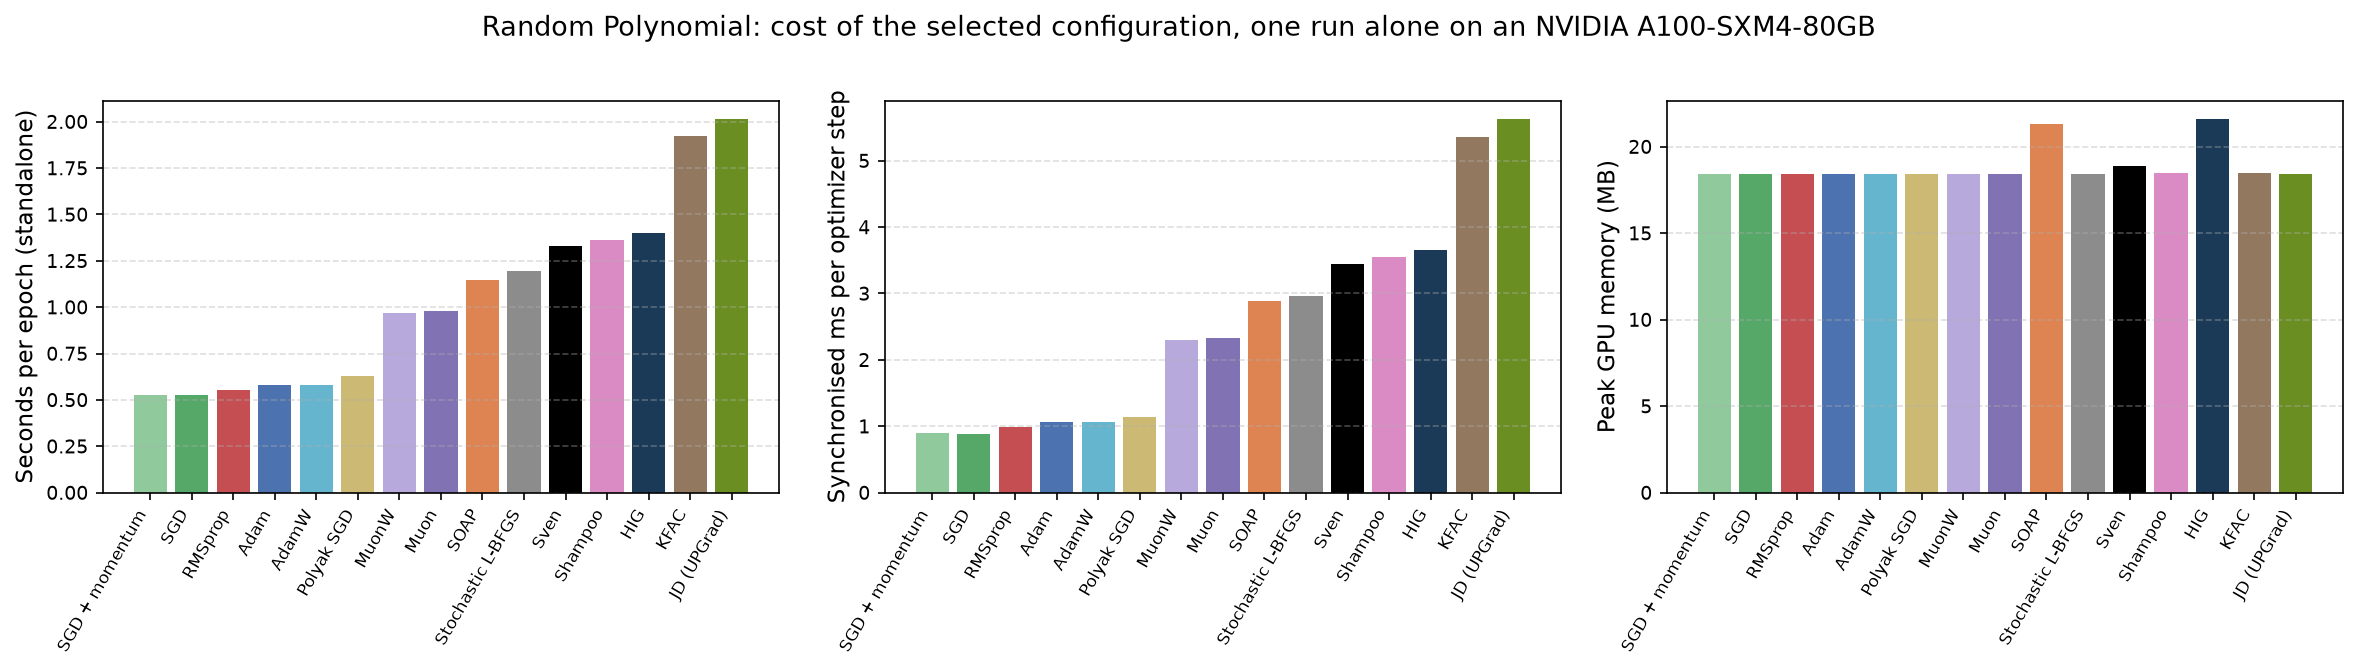

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
d = eff.sort_values('epoch_s')
x = np.arange(len(d))
colors = [style.method_color(m) for m in d['method']]
for ax, col, label in zip(axs, ['epoch_s', 'ms_per_step', 'peak_gpu_mem_mb'],
                          ['Seconds per epoch (standalone)',
                           'Synchronised ms per optimizer step',
                           'Peak GPU memory (MB)']):
    ax.bar(x, d[col], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels([style.method_label(m) for m in d['method']], rotation=60,
                       ha='right', fontsize=8)
    ax.set_ylabel(label, fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', ls='--', alpha=0.4)
fig.suptitle(f'{TITLE}: cost of the selected configuration, one run alone on an '
             f'{eff["gpu_timing"].dropna().iloc[0] if eff["gpu_timing"].notna().any() else "A100"}',
             fontsize=13)
fig.tight_layout()
hf.save(fig, scan, 'standalone_cost_bars')
plt.show()

In [17]:
TCOLS = ['target', 'target_value', 'display', 'n_runs', 'n_reached', 'n_never_reached',
         'n_diverged', 'elig_conf', 'all_reached', 'epochs', 'epochs_std', 'steps',
         'examples', 'sync_train_s', 'standalone_s']
ttt = hl.time_to_target_table(SCAN)
print(f'targets: ' + ', '.join(f'{k} = {v:.4g}' for k, v in ttt.attrs['targets'].items()))
hl.print_table(ttt[TCOLS], f'{TITLE} -- time to target (confirmation runs; seconds per '
                           f'epoch from {ttt.attrs["seconds_per_epoch_from"]})')

targets: easy (2x median) = 0.4345, median method = 0.2173, hard (0.5x median) = 0.1086

### Random Polynomial -- time to target (confirmation runs; seconds per epoch from polynomial_scan_timing)
| target | target_value | display | n_runs | n_reached | n_never_reached | n_diverged | elig_conf | all_reached | epochs | epochs_std | steps | examples | sync_train_s | standalone_s |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| easy (2x median) | 0.4345 | Sven | 15 | 15 | 0 | 0 | True | True | 2.267 | 1.944 | 707.2 | 2.263e+04 | 6.864 | 3.012 |
| easy (2x median) | 0.4345 | Adam | 15 | 15 | 0 | 0 | True | True | 3.733 | 2.658 | 1165 | 3.727e+04 | 3.499 | 2.166 |
| easy (2x median) | 0.4345 | AdamW | 15 | 15 | 0 | 0 | True | True | 3.733 | 2.658 | 1165 | 3.727e+04 | 3.574 | 2.166 |
| easy (2x median) | 0.4345 | HIG | 15 | 15 | 0 | 0 | True | True | 1.333 | 0.6172 | 416 | 1.331e+04 | 6.021 | 1.869 |
| easy (2x median) | 0.4345 | JD (UPGrad) | 15 | 15 | 0 | 0 | True | True | 

,target,target_value,display,n_runs,n_reached,n_never_reached,n_diverged,elig_conf,all_reached,epochs,epochs_std,steps,examples,sync_train_s,standalone_s
0,easy (2x median),0.434547,Sven,15,15,0,0,True,True,2.266667,1.944467,707.200000,22630.400000,6.864319,3.011851
1,easy (2x median),0.434547,Adam,15,15,0,0,True,True,3.733333,2.658320,1164.800000,37273.600000,3.499303,2.165946
2,easy (2x median),0.434547,AdamW,15,15,0,0,True,True,3.733333,2.658320,1164.800000,37273.600000,3.574163,2.166437
3,easy (2x median),0.434547,HIG,15,15,0,0,True,True,1.333333,0.617213,416.000000,13312.000000,6.020645,1.868543
4,easy (2x median),0.434547,JD (UPGrad),15,15,0,0,True,True,5.066667,2.737743,1580.800000,50585.600000,11.522464,10.203621
5,easy (2x median),0.434547,KFAC,15,15,0,0,True,True,8.600000,3.601587,2683.200000,85862.400000,70.218432,16.538339
6,easy (2x median),0.434547,Stochastic L-BFGS,15,1,1,13,False,False,6.000000,0.000000,1872.000000,59904.000000,20.969528,7.161737
7,easy (2x median),0.434547,Muon,15,15,0,0,True,True,2.466667,0.990430,769.600000,24627.200000,4.009999,2.413608
8,easy (2x median),0.434547,MuonW,15,15,0,0,True,True,3.066667,1.533747,956.800000,30617.600000,5.053419,2.964613
9,easy (2x median),0.434547,Polyak SGD,15,15,0,0,True,True,5.466667,4.611580,1705.600000,54579.200000,5.893669,3.424424


## 7. Robustness: how much of each grid blew up, and where Sven's divergences sit

Two counts, and they are not the same number.  `n_recorded` is the **lifecycle** count
(`status == "diverged"`: the run raised, or produced a non-finite batch loss and was
stopped).  `n_diverged` is the **analysis** count `style.is_diverged` --- recorded, *or* a
non-finite final value, *or* a finite blow-up to more than 10x the initial validation loss
--- and it is the one that governs selection and every table in this notebook.  It is the
wider of the two, and quoting the narrow one is exactly how "Sven never diverges" gets
written down: the cell below prints both, for this scan and for **every tuning grid in the
campaign** (`campaign_sven_*`, recomputed from the records rather than quoted --- the
`EXPERIMENTS.md` section 7 count was written before the CIFAR-CE `rtol` extension started
adding Sven runs to the denominator).

`n_configs_all_bad` is the number of grid **points** that lost every seed --- configurations
a tuning search would have had to throw away entirely.

**Where** the divergences sit is a per-scan question and is answered per scan.  The
mechanistic story --- a loose `rtol` inverts near-noise Gram directions, and the risk grows
with the learning rate --- is visible on `toy_1d_scan`; on this scan the printed verdict
(`hf.divergence_pattern`) says what the grid actually shows, which on two of the four MLP
scans is "no divergence anywhere".


### Random Polynomial -- divergences across the whole tuning grid (1630 runs)
| method | display | n_runs | n_recorded | n_diverged | n_failed | frac_diverged | n_configs | n_configs_any_bad | n_configs_all_bad | frac_configs_all_bad |
|---|---|---|---|---|---|---|---|---|---|---|
| LBFGS | Stochastic L-BFGS | 225 | 204 | 204 | 0 | 0.9067 | 45 | 45 | 34 | 0.7556 |
| KFAC | KFAC | 50 | 15 | 21 | 0 | 0.42 | 10 | 5 | 3 | 0.3 |
| SGDm | SGD + momentum | 50 | 12 | 12 | 0 | 0.24 | 10 | 3 | 1 | 0.1 |
| SGD | SGD | 50 | 8 | 8 | 0 | 0.16 | 10 | 2 | 1 | 0.1 |
| SOAP | SOAP | 50 | 2 | 4 | 0 | 0.08 | 10 | 1 | 0 | 0 |
| RMSprop | RMSprop | 50 | 0 | 3 | 0 | 0.06 | 10 | 2 | 0 | 0 |
| HIG | HIG | 150 | 3 | 3 | 0 | 0.02 | 30 | 1 | 0 | 0 |
| MuonW | MuonW | 50 | 0 | 1 | 0 | 0.02 | 10 | 1 | 0 | 0 |
| Sven | Sven | 720 | 0 | 4 | 0 | 0.005556 | 144 | 4 | 0 | 0 |
| JD | JD (UPGrad) | 30 | 0 | 0 | 0 | 0 | 6 | 0 | 0 | 0 |
| AdamW | AdamW | 50 | 0 | 0 | 0 | 0 | 10 | 0 | 0 | 0 |
| Adam | Adam | 50 | 0 | 0 | 0 

Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 29 runs from ../experiment_results/_cache/exp_gpt2_small_comparison.slim.pkl (slim cache)


Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
Loaded 210 runs from ../experiment_results/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_ce_scan.slim.pkl (slim cache)


Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_labelreg_scan.slim.pkl (slim cache)
Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_ce_scan.slim.pkl (slim cache)
Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_labelreg_scan.slim.pkl (slim cache)


Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)
Loaded 1360 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)


...

Loaded 15 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)
Loaded 3600 runs from ../experiment_results/_cache/rebuttal_overparam_mnist_scan.slim.pkl (slim cache)


Loaded 4320 runs from ../experiment_results/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (slim cache)


Loaded 3240 runs from ../experiment_results/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)


Loaded 120 runs from ../experiment_results/_cache/toy_1d_microbatch_scan.slim.pkl (slim cache)
Loaded 100 runs from ../experiment_results/_cache/toy_1d_paramfrac_scan.slim.pkl (slim cache)


Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
Sven on-grid campaign-wide: 688 of 7867 runs diverged under the analysis rule (8.7%), 39 of them recorded as such by the runner; 16 of 22 tuning grids affected

### Sven's on-grid divergences per tuning grid, campaign-wide (grids with none are omitted)
| scan | n_runs | n_diverged | n_recorded | frac_diverged |
|---|---|---|---|---|
| rebuttal_overparam_polynomial_scan | 1800 | 252 | 0 | 0.14 |
| toy_1d_scan | 900 | 194 | 0 | 0.2156 |
| rebuttal_overparam_toy_1d_scan | 720 | 111 | 0 | 0.1542 |
| rebuttal_batchsize_polynomial_scan | 480 | 35 | 0 | 0.07292 |
| mnist_paramfrac_labelreg_scan | 100 | 24 | 14 | 0.24 |
| polynomial_paramfrac_scan | 100 | 20 | 15 | 0.2 |
| toy_1d_paramfrac_scan | 100 | 14 | 1 | 0.14 |
| mnist_paramfrac_ce_scan | 100 | 12 | 9 | 0.12 |
| mnist_kappaScan_labelRegression | 210 | 10 | 0 | 0.04762 |
| cifar10_resnet_scan_labelRegression | 90 | 5 | 0 | 0.05556 |
| polynomial_scan | 7

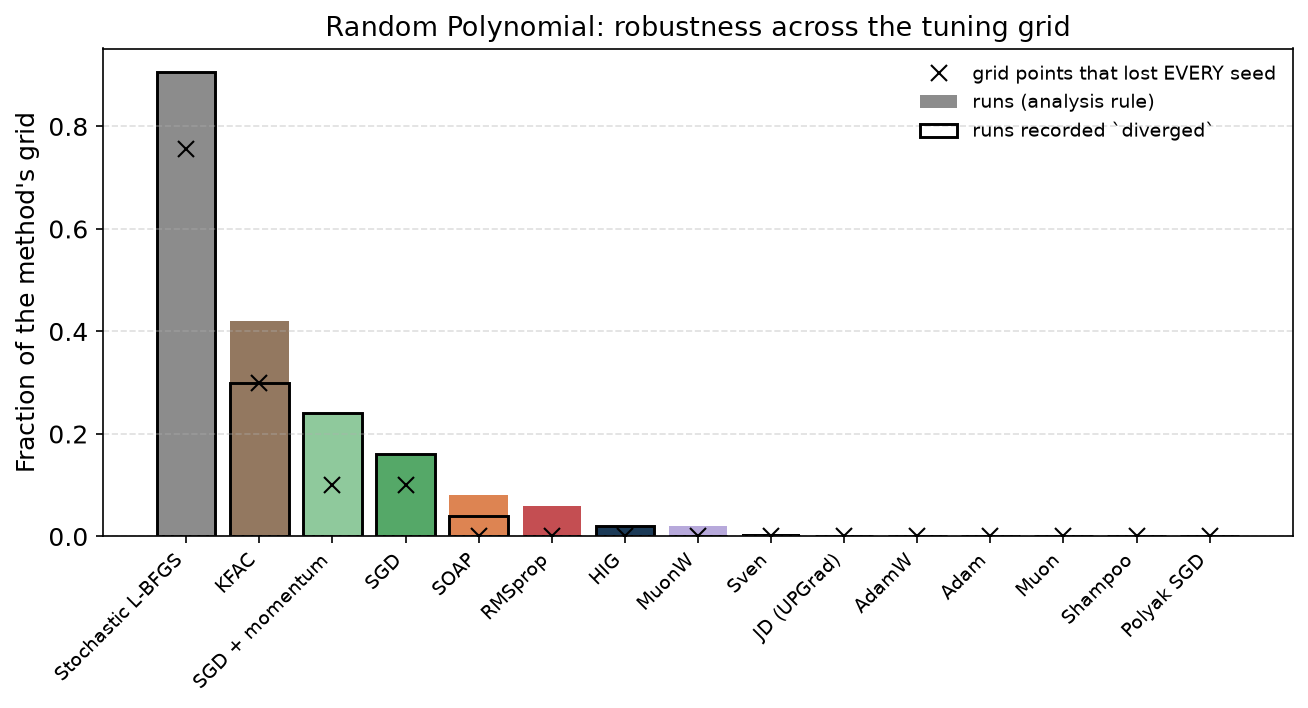

In [18]:
div = hf.divergence_by_method(scan.df)
hl.print_table(div, f'{TITLE} -- divergences across the whole tuning grid '
                    f'({len(scan.df)} runs)')
print(f'  {div.attrs["counts"]}')
print(f'  scan total: {int(div["n_diverged"].sum())} diverged of {int(div["n_runs"].sum())} '
      f'runs ({div["n_diverged"].sum() / div["n_runs"].sum():.1%}), '
      f'{int(div["n_recorded"].sum())} of them recorded as such')

# Campaign-wide, computed over every tuning grid in the results root -- the number
# EXPERIMENTS.md section 7 quotes, recomputed here because its denominator is still
# growing while the CIFAR-CE rtol extension lands.
campaign = hf.campaign_divergence(verbose=True)
hl.print_table(campaign[campaign['n_diverged'] > 0],
               "Sven's on-grid divergences per tuning grid, campaign-wide "
               "(grids with none are omitted)")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(div))
ax.bar(x, div['frac_diverged'], color=[style.method_color(m) for m in div['method']],
       label='runs (analysis rule)')
ax.bar(x, div['n_recorded'] / div['n_runs'], color='none', edgecolor='k', lw=1.4,
       label='runs recorded `diverged`')
ax.plot(x, div['frac_configs_all_bad'], 'kx', ms=8, ls='none',
        label='grid points that lost EVERY seed')
ax.set_xticks(x)
ax.set_xticklabels(div['display'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fraction of the method\'s grid', fontsize=12)
ax.set_title(f'{TITLE}: robustness across the tuning grid', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', ls='--', alpha=0.4)
fig.tight_layout()
hf.save(fig, scan, 'divergence_by_method')
plt.show()

VERDICT for this scan: 4 of 720 Sven runs diverge, at rtol 1e-05, 0.001 (of 1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1) and lr 1
  worst cell: rtol=1e-05, lr=1: 3/30 (10%)
  confined to the low end of the rtol grid: False; fraction rises monotonically with lr: False
  divergence fraction by learning rate: {1.0: 0.0222}

### the (rtol, lr) cells with a divergence
| rtol | lr | frac | n_diverged | n |
|---|---|---|---|---|
| 1e-05 | 1 | 0.1 | 3 | 30 |
| 0.001 | 1 | 0.03333 | 1 | 30 |


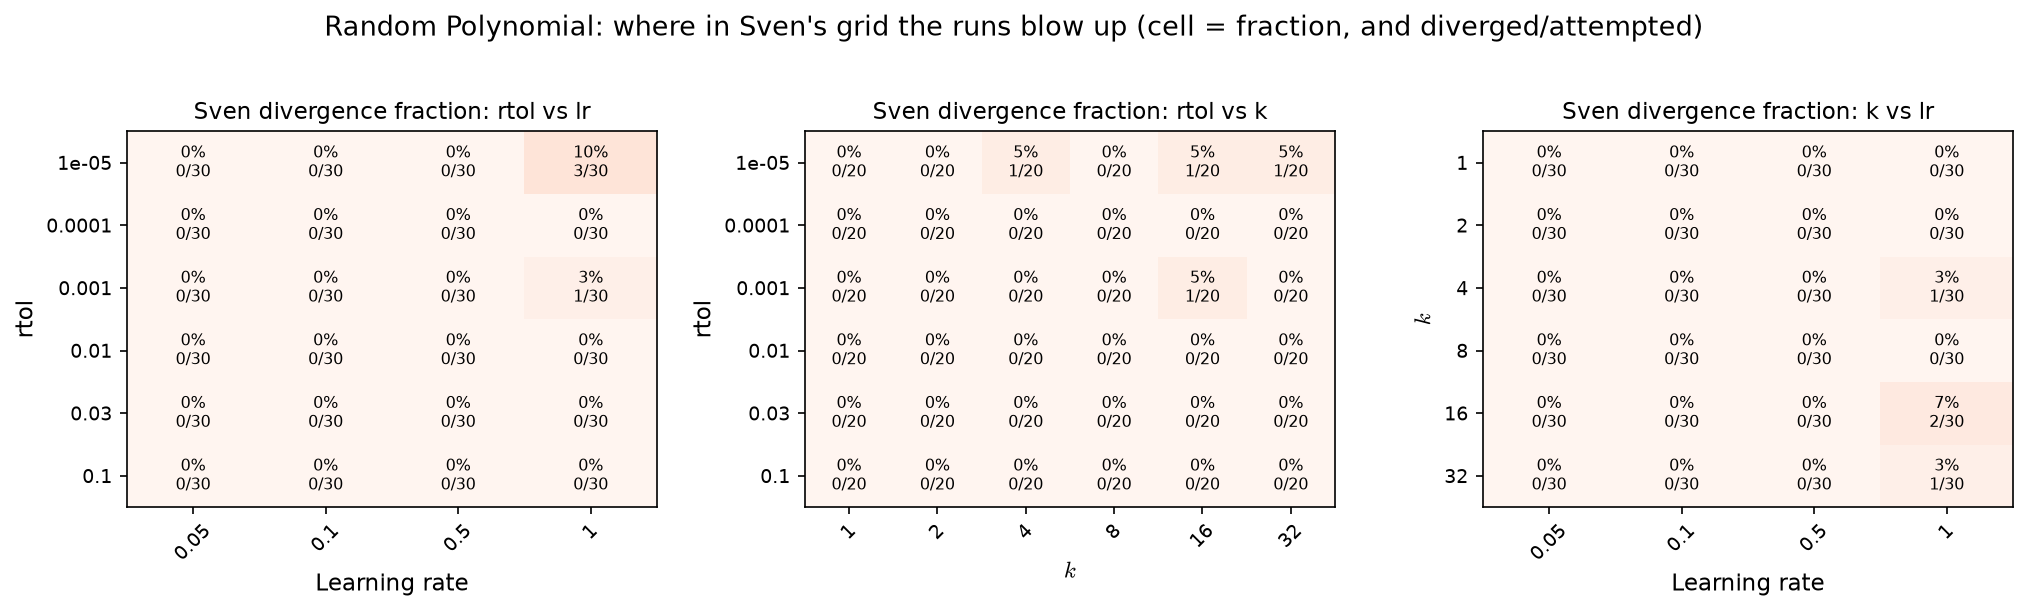

In [19]:
# Where Sven's divergences sit -- read off THIS grid, not asserted.  On toy_1d_scan the
# pattern is mechanistic and worth stating: Sven blows up when rtol is at or near the
# BOTTOM of its grid, i.e. when the cut is loose enough to invert near-noise Gram
# directions, and the risk grows with the learning rate.  On a grid with no divergence the
# verdict below says so instead.  Blank heatmap cells are grid points that do not exist.
pattern = hf.divergence_pattern(scan.df)
print(f'VERDICT for this scan: {pattern["summary"]}')
if pattern['any']:
    print(f'  worst cell: {pattern["worst_cell"]}')
    print(f'  confined to the low end of the rtol grid: '
          f'{pattern["confined_to_low_rtol"]}; fraction rises monotonically with lr: '
          f'{pattern["rises_with_lr"]}')
    print(f'  divergence fraction by learning rate: {pattern["frac_by_lr"]}')
    hl.print_table(pattern['cells'], 'the (rtol, lr) cells with a divergence')
else:
    print('  -> the heatmaps below are all zeros, and no rtol / lr pattern is claimed '
          'for this scan')

panels = [('rtol', 'lr', 'rtol', 'Learning rate'), ('rtol', 'k', 'rtol', '$k$'),
          ('k', 'lr', '$k$', 'Learning rate')]
fig, axs = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 4.2))
im = None
for ax, (idx, col, ylab, xlab) in zip(np.atleast_1d(axs), panels):
    frac, counts = hf.sven_divergence_grid(scan.df, index=idx, columns=col)
    if frac is None:
        ax.axis('off')
        continue
    im = hf.plot_divergence_grid(frac, ax, counts, ylabel=ylab, xlabel=xlab,
                                 title=f'Sven divergence fraction: {idx} vs {col}')
    ax.tick_params(labelsize=9); ax.xaxis.label.set_size(11); ax.yaxis.label.set_size(11)
fig.suptitle(f'{TITLE}: where in Sven\'s grid the runs blow up '
             f'(cell = fraction, and diverged/attempted)', fontsize=13)
fig.tight_layout()
hf.save(fig, scan, 'sven_divergence_grid')
plt.show()

## 8. Sven's hyperparameter landscape

$\log_{10}$ of the seed-mean final validation loss over the $(k, \eta)$ grid, one panel
per `rtol`, with the **selected** configuration ringed in white.  A blank cell is a
configuration that is not *eligible* --- at most half of its seeds finished --- so the
white regions are the divergence map of section 7 seen from the other side.

The table below says, for each swept axis, whether the selected value sits in the interior
of the grid or on an edge.  `k = B` is the uncapped-rank configuration: a natural maximum,
not an edge that wants extending.  Both the heatmap and the edge table are built from the
grid points the **records** contain, so an extension round (the campaign added one on
CIFAR-CE, `rtol` 0.03 / 0.1 / 0.3 at `k = 128`) shows up here automatically the moment its
runs land --- nothing here is a hard-coded grid.

In [20]:
edges = hf.grid_edges(scan, sel_sven)
hl.print_table(edges, f'{TITLE} -- where the selected Sven configuration sits on each axis')
print(f'  selected: {hl.config_label(sven_entry)}   (overrides: {sven_entry["overrides"]})')
if edges.attrs['on_edge']:
    print(f'  REMAINING GRID EDGE: {edges.attrs["on_edge"]} -- the optimum is at the end '
          f'of the swept range, so the grid does not bracket it')
else:
    print('  no remaining grid edge: every selected value is bracketed by the sweep '
          '(k = B aside, which is the uncapped-rank maximum)')


### Random Polynomial -- where the selected Sven configuration sits on each axis
| axis | selected | n_points | grid | position |
|---|---|---|---|---|
| k | 16 | 6 | 1, 2, 4, 8, 16, 32 | interior |
| lr | 0.5 | 4 | 0.05, 0.1, 0.5, 1 | interior |
| rtol | 0.03 | 6 | 1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1 | interior |
  selected: k=16, lr=0.5, rtol=0.03   (overrides: mode=svd k_values=[16] lrs=[0.5] rtol=[0.03])
  no remaining grid edge: every selected value is bracketed by the sweep (k = B aside, which is the uncapped-rank maximum)


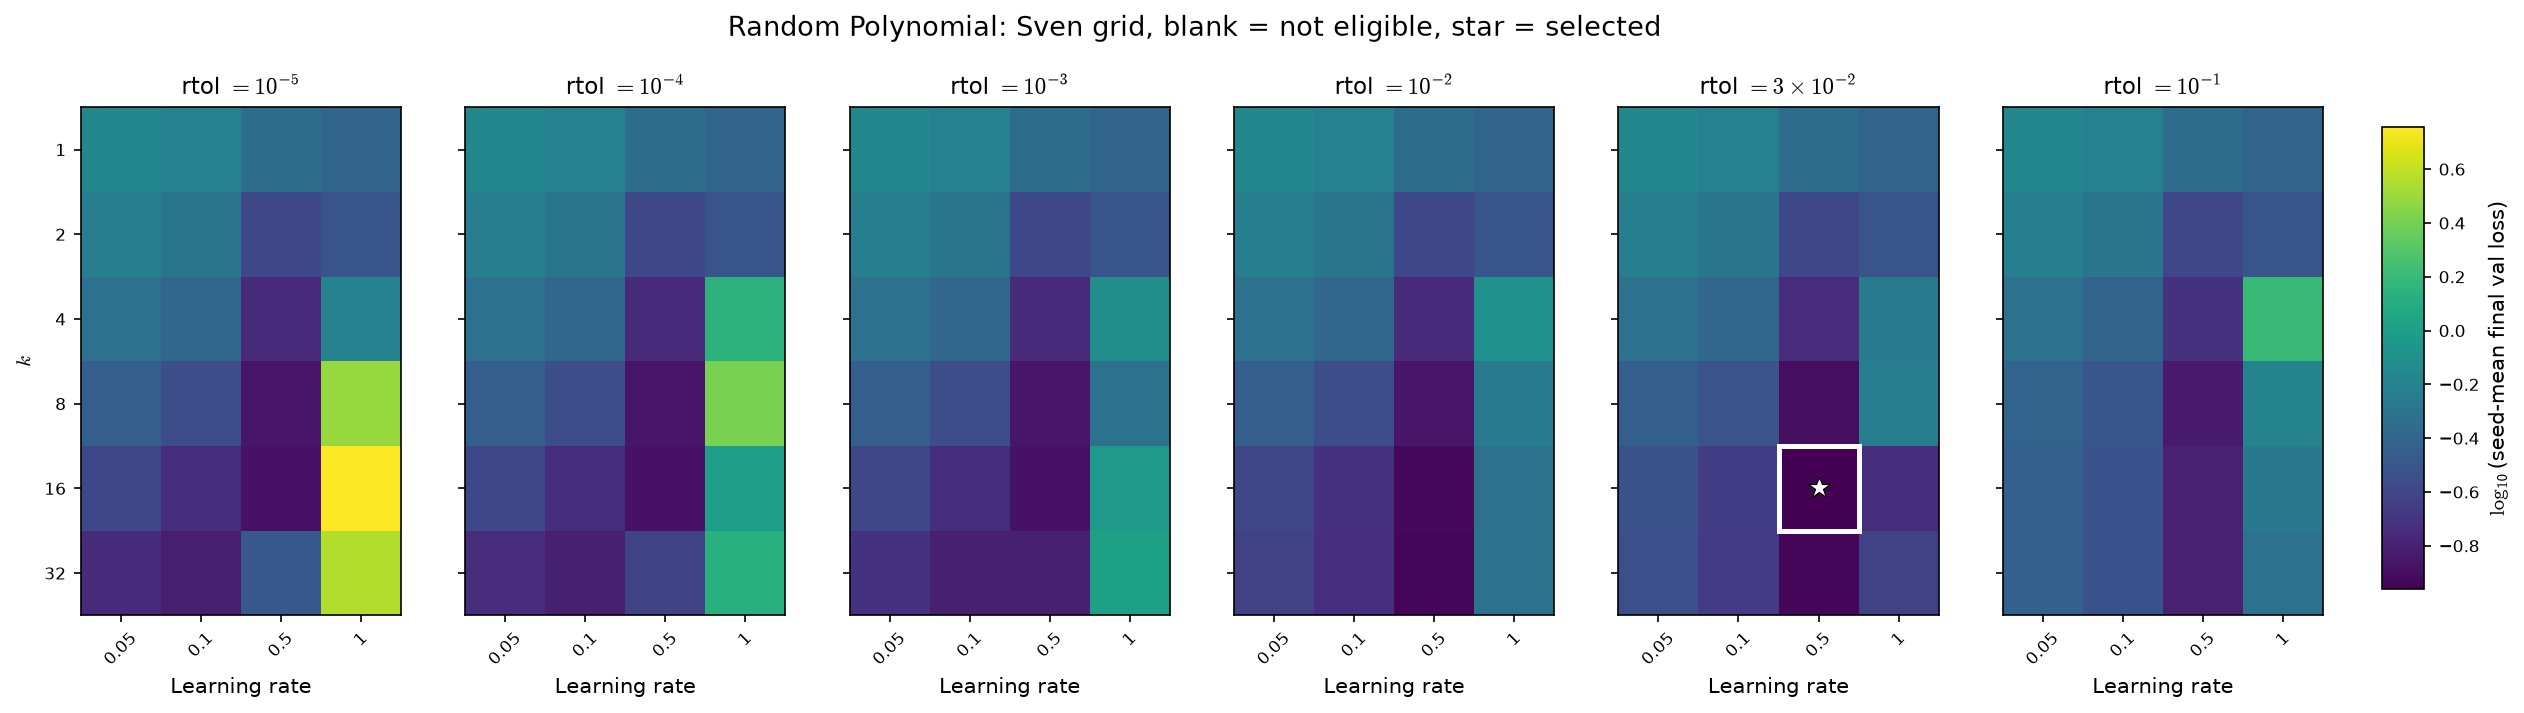

In [21]:
cfg_grid = hf.sven_grid_table(scan)
fig, axs = plt.subplots(1, len(scan.rtols), figsize=(3.3 * len(scan.rtols), 4.4),
                        squeeze=False)
im = sa.plot_hparam_heatmap(scan, axs[0])
for ax, rtol in zip(axs[0], scan.rtols):
    piv = (cfg_grid[cfg_grid['rtol'] == rtol]
           .pivot_table(values='score', index='k', columns='lr', dropna=False))
    if np.isclose(float(sel_sven['rtol']), rtol):
        hf.plot_selected_marker(ax, piv, sel_sven)
    ax.tick_params(labelsize=8)
    ax.xaxis.label.set_size(10); ax.yaxis.label.set_size(10); ax.title.set_size(11)
fig.subplots_adjust(right=0.88)
cb = fig.colorbar(im, cax=fig.add_axes([0.90, 0.15, 0.014, 0.7]))
cb.set_label('$\\log_{10}$(seed-mean final val loss)', size=10)
cb.ax.tick_params(labelsize=8)
fig.suptitle(f'{TITLE}: Sven grid, blank = not eligible, star = selected', y=1.02,
             fontsize=13)
hf.save(fig, scan, 'sven_heatmap_by_rtol')
plt.show()

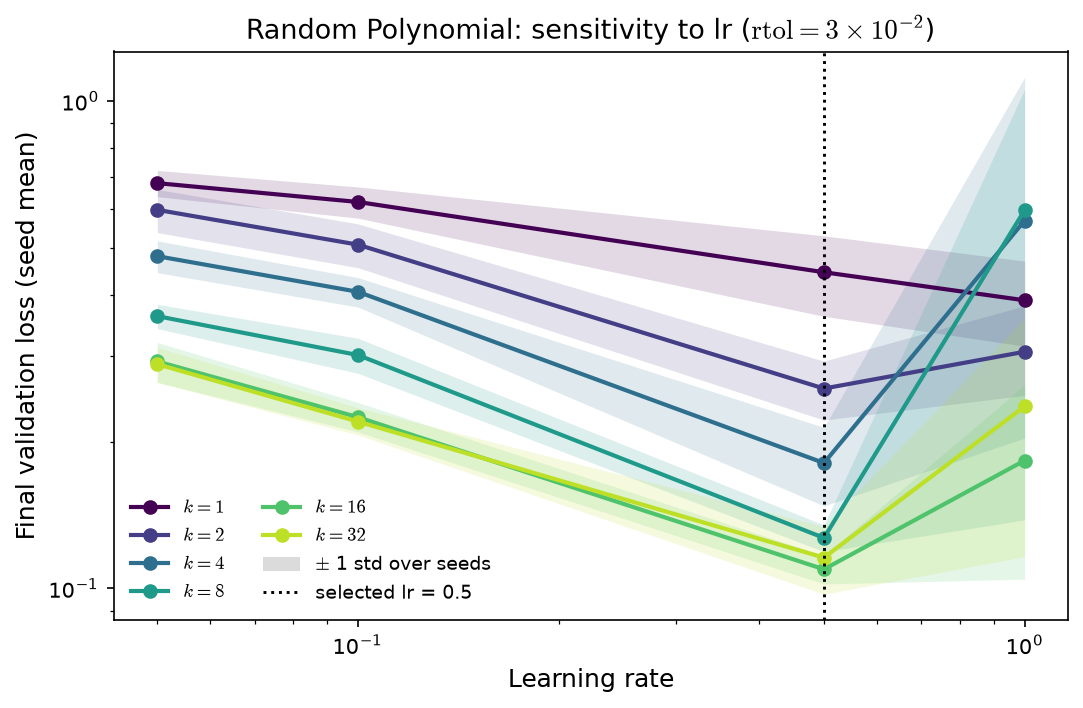

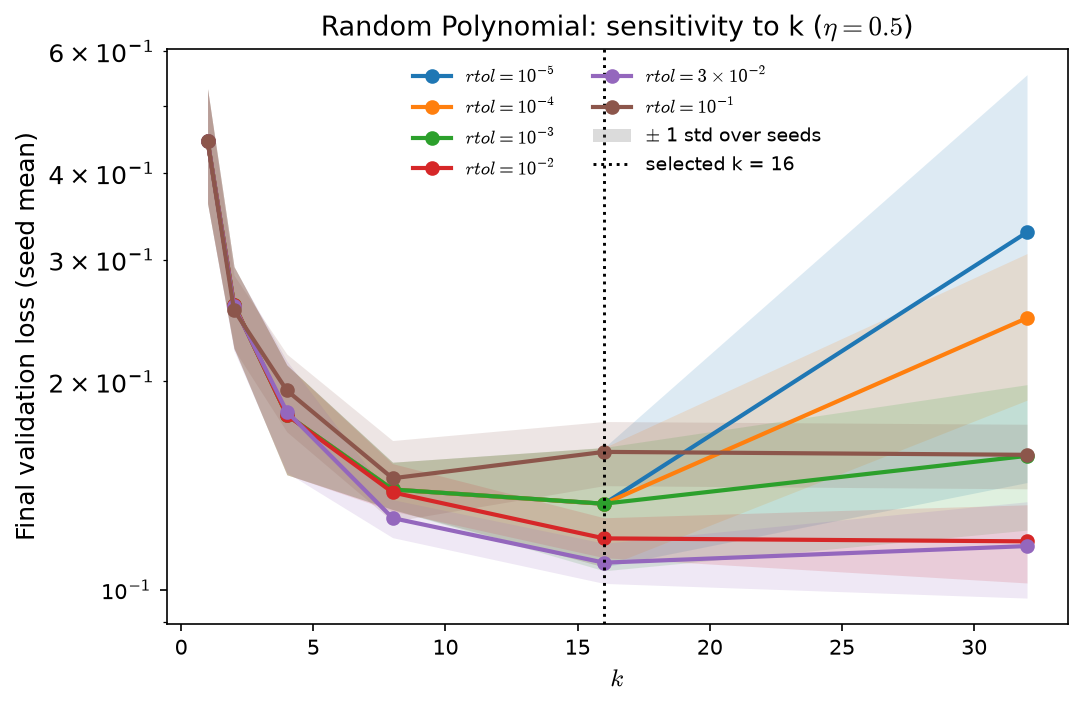

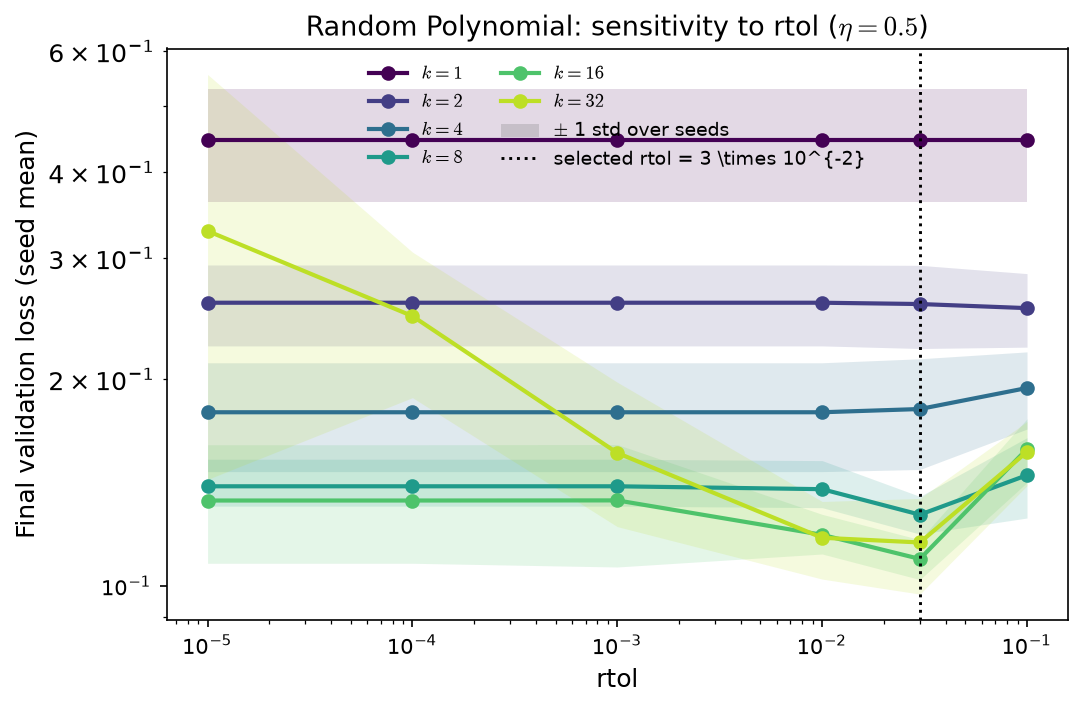

In [22]:
# One-dimensional slices through the optimum: the third axis is pinned at its value in
# the selected configuration, so each line is a plain slice and not a best-case envelope.
for x, lines, fname in [('lr', 'k', 'lr_sensitivity'),
                        ('k', 'rtol', 'k_effect'),
                        ('rtol', 'k', 'rtol_effect')]:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    pinned = sa.plot_sensitivity(scan, ax, x=x, lines=lines)
    other = ({'k', 'lr', 'rtol'} - {x, lines}).pop()
    other_tex = {'k': 'k', 'lr': '\\eta', 'rtol': '\\mathrm{rtol}'}[other]
    ax.axvline(float(sel_sven[x]), color='k', ls=':', lw=1.4,
               label=f'selected {x} = {sa.fmt(float(sel_sven[x]))}')
    ax.set_title(f'{TITLE}: sensitivity to {x} (${other_tex} = {sa.fmt(pinned)}$)',
                 fontsize=13)
    ax.legend(ncol=2, fontsize=9)
    ax.tick_params(labelsize=10); ax.xaxis.label.set_size(12); ax.yaxis.label.set_size(12)
    fig.tight_layout()
    hf.save(fig, scan, fname)
    plt.show()

## 9. Data-seed replicates: between-instance against between-seed spread

The confirmation pass re-drew the **problem** three times (`data_seed`), five model seeds
each.  Three numbers must not be confused:

* `val_conf` --- pooled over all 15 runs, i.e. seeds *and* instances;
* `val_conf_dsspread` --- the std of the three per-instance **means**: how much the answer
  depends on which random problem was drawn;
* `val_conf_seedspread` --- the seed band averaged over the instances.

`ratio_instance_over_seed` above 1 says the draw of the problem moves the answer more than
the seed does, and no single-instance number should then be quoted without it.  It is also
why the *pooled* selection-optimism gap in section 2 is not selection optimism: it compares
15 runs on 3 problems against 5 tuning runs on 1.


### Random Polynomial -- between-instance vs between-seed spread (data seeds [2000, 2001, 2002])
| method | display | n_data_seeds | val_conf | val_conf_dsmean | val_conf_dsspread | val_conf_seedspread | val_conf_ds0 | ratio_instance_over_seed |
|---|---|---|---|---|---|---|---|---|
| HIG | HIG | 3 | 0.08406 | 0.08406 | 0.02679 | 0.008164 | 0.07169 | 3.282 |
| Sven | Sven | 3 | 0.1388 | 0.1388 | 0.05704 | 0.02594 | 0.1102 | 2.199 |
| JD | JD (UPGrad) | 3 | 0.1635 | 0.1635 | 0.05239 | 0.02183 | 0.1409 | 2.4 |
| SOAP | SOAP | 3 | 0.1818 | 0.1818 | 0.05072 | 0.02425 | 0.1527 | 2.091 |
| PolyakSGD | Polyak SGD | 3 | 0.1997 | 0.1997 | 0.09543 | 0.03328 | 0.1395 | 2.868 |
| Muon | Muon | 3 | 0.207 | 0.207 | 0.06824 | 0.02368 | 0.1622 | 2.882 |
| KFAC | KFAC | 3 | 0.2118 | 0.2118 | 0.06054 | 0.02409 | 0.1895 | 2.513 |
| RMSprop | RMSprop | 3 | 0.2173 | 0.2173 | 0.06076 | 0.02245 | 0.1781 | 2.706 |
| MuonW | MuonW | 3 | 0.2313 | 0.2313 | 0.07823 | 0.02197 | 0.1837 | 3.56 |
| Adam | Adam | 3 |

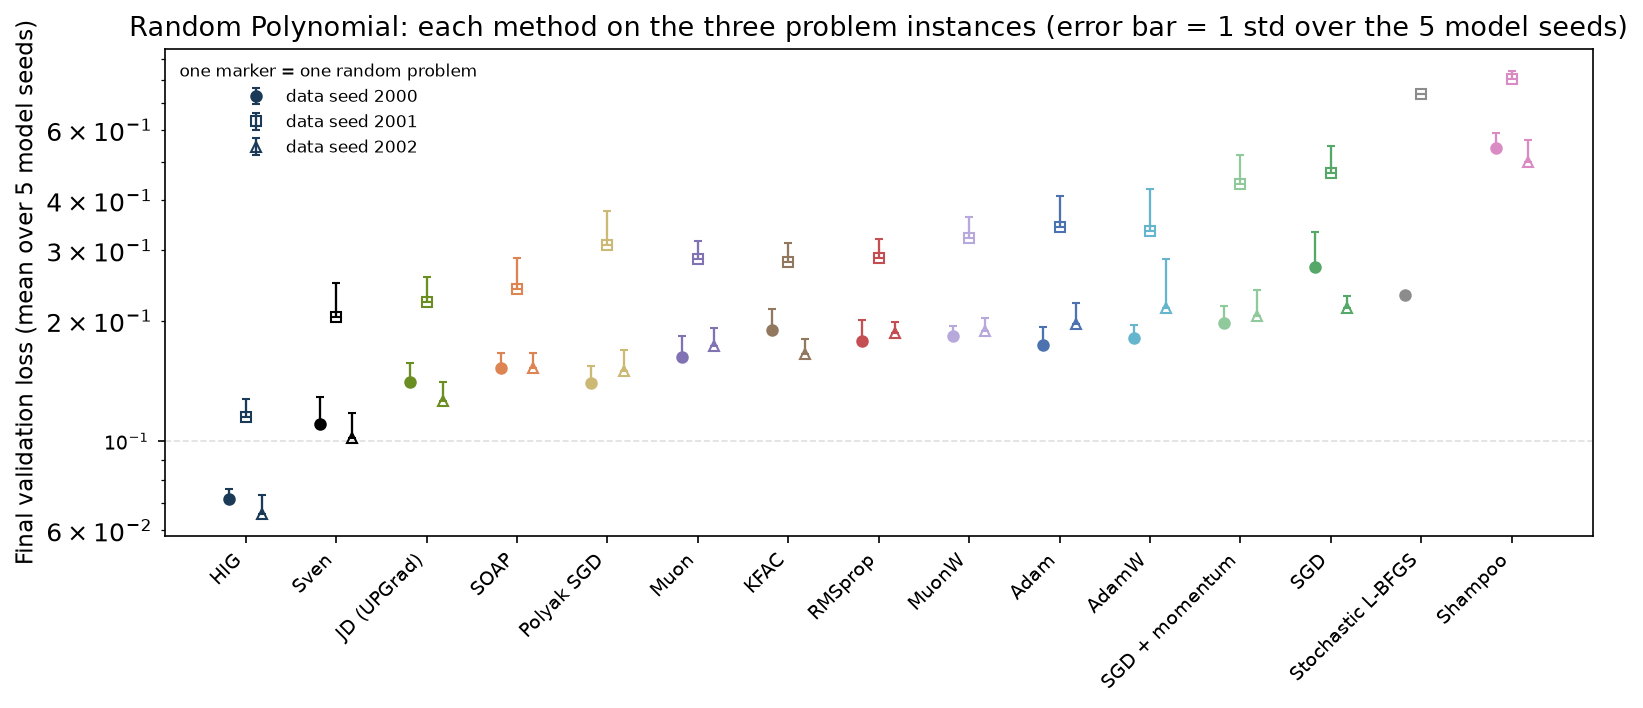

In [23]:
spread = hf.instance_spread(SCAN, table=conf)
hl.print_table(spread, f'{TITLE} -- between-instance vs between-seed spread '
                       f'(data seeds {spread.attrs["data_seeds"]})')
print(f'  median ratio (instance spread / seed spread): '
      f'{spread["ratio_instance_over_seed"].median(skipna=True):.2f}')

ds = hl.data_seed_table(SCAN)
hl.print_table(ds, f'{TITLE} -- per data seed (each seed is a DIFFERENT random problem)')

fig, ax = plt.subplots(figsize=(11, 5))
hf.plot_instance_spread(SCAN, ax, table=conf)
ax.set_title(f'{TITLE}: each method on the three problem instances '
             f'(error bar = 1 std over the 5 model seeds)', fontsize=13)
ax.tick_params(labelsize=9); ax.yaxis.label.set_size(11)
fig.tight_layout()
hf.save(fig, scan, 'data_seed_replicates')
plt.show()

## 10. Spectra and mechanism --- pointer

The singular-value spectra, the `utr` diagnostics (is the residual in the truncated
tail?), the rank actually used against $k$, and the probe-set Jacobian spectra along the
trajectories of Sven *and* the baselines are **not** in this notebook.  They read
`polynomial_scan_diag/` (dense per-step spectra for the selected configuration of every method) and
the cached checkpoint spectra under `analysis/ckpt_spectra/`, and they live in
`analysis/spectra_analysis.ipynb` and `analysis/comparisons.ipynb` (`analysis/ckpt_tools.py`,
`analysis/sv_diagnostics.py`).  One mechanism number worth carrying here: on the polynomial
task the $k = 16$ truncation discards about **41%** of the residual energy while $k = 32$
keeps about **74%**.

## 11. What this scan shows

In [24]:
nums = hf.closing_numbers(SCAN, conf=conf, eff=eff, ttt=ttt, budget_tbl=bt, div=div,
                          paired_tbl=pv, bon=curves, df=scan.df, campaign=campaign)

--- numbers behind the closing cell: Random Polynomial (polynomial_scan) ---
  scan                             polynomial_scan
  title                            Random Polynomial
  n_methods                        15
  sven_config                      k=16, lr=0.5, rtol=0.03
  sven_rank_val                    2
  sven_val                         0.138788
  sven_val_std                     0.0550807
  sven_test                        0.136013
  sven_finished                    15
  sven_attempted                   15
  sven_gap_rel                     0.00636824
  best_method                      HIG
  best_val                         0.0840584
  sven_over_best                   1.65109
  n_paired                         14
  n_sven_better_sig                12
  n_sven_worse_sig                 1
  n_paired_inconclusive            1
  fastest_method                   SGD + momentum
  fastest_epoch_s                  0.525379
  sven_epoch_s                     1.32876
  sven_ms_per_st

*(every number below is printed by the cell above; nothing here is typed in by hand)*

* **Where Sven lands.** On the confirmation seeds Sven is `sven_rank_val` of
  `n_methods` on validation loss with the configuration `sven_config`, against
  `best_method` at `best_val`.  The test loss and
  outcome in section 2 rank it the
  same way or close to it --- validation and test agree on this task, which is the
  cheapest evidence that the selection did not overfit the split.
* **Against each baseline, paired.** `n_sven_better_sig` of `n_paired` paired
  differences favour Sven with an interval that excludes zero, `n_sven_worse_sig` go the
  other way and `n_paired_inconclusive` straddle zero.  With 5 (or 15) pairs and no
  multiplicity correction those counts are a reading aid, not a test.
* **What it costs.** `sven_epoch_s` s per epoch standalone against `fastest_epoch_s` s
  for `fastest_method` --- a factor `sven_slowdown_vs_fastest` --- at
  `sven_ms_per_step` ms per synchronised optimizer step and `sven_peak_mem_mb` MB peak.
  Per step it is neither the cheapest nor the dearest of the field:
  `n_ms_per_step_cheaper_than_sven` selected configurations cost less per step and
  `n_ms_per_step_dearer_than_sven` cost more, with
  `ms_per_step_just_below_sven` immediately below it,
  `ms_per_step_just_above_sven` immediately above and `ms_per_step_dearest` the
  dearest --- the neighbours are printed because *which* methods those are changes from
  scan to scan.
* **Time to target, and what the step axis really says.** At the pre-declared
  median-method target `target_median`, Sven reaches it in `sven_ttt_epochs` epochs /
  `sven_ttt_s` s of synchronised training time.  That is rank
  `sven_rank_epochs_to_target` of the `n_reached_target` methods that reach the target at
  all, behind `ttt_fewest_epochs_method` at `ttt_fewest_epochs` epochs: **Sven is near the
  front of the epoch axis, not ahead of it**, and `n_methods_never_reached` method(s)
  never reach the target at all --- counted, not dropped.  On the time axis the ordering
  changes again, which is why section 3 draws all three.
* **Tuning budget --- and it is not settled in Sven's favour.** Sven's grid is
  `sven_grid_points` points but only `sven_distinct` of them are distinct trajectories
  (`sven_distinct_frac`): where the rtol-rank stays below $k$ the truncation binds nothing
  and the point is the same run.  That says the extra grid points were partly redundant,
  which if anything *strengthens* the objection rather than answering it.  The answer is
  the equal-budget reading of the best-of-$n$ curves: at `budget_equal_n` random trials
  Sven's expected best is `sven_best_of_n`, which is rank
  `sven_budget_rank_at_equal_n` of `n_methods_at_equal_n` ---
  `n_better_than_sven_at_equal_n` method(s) do better from the same number of trials,
  the best of them being `best_at_equal_n` at `best_value_at_equal_n`, and Sven needs
  `sven_n_to_match_best_at_equal_n` trials to match that (`None` = it never does).  Sven's
  standing on this scan is therefore a statement about a *well-tuned* Sven, and the
  tuning cost is part of the method.
* **Robustness, honestly.** `sven_grid_diverged` of Sven's `sven_grid_runs` on-grid runs
  on this scan blow up under the analysis rule (`sven_grid_frac`), against
  `sven_grid_recorded` recorded as `diverged` by the runner --- the two counts are
  different questions and the wide one is the one that governs selection.  Campaign-wide,
  over all `campaign_grids` tuning grids, it is `campaign_sven_diverged` of
  `campaign_sven_runs` (`campaign_sven_frac`) against `campaign_sven_recorded` recorded,
  on `campaign_grids_affected` grids.  Section 7 says *where* for this scan, and only
  where the counts support it: `sven_div_pattern`. The worst method on this
  scan is `worst_method` at `worst_frac` of its grid.
* **Selection optimism** is the *tuning-instance* gap in section 2
  (`gap rel, tuning instance`), `sven_gap_rel` for Sven here.  The pooled column beside it is mostly which random problem was drawn, not selection --- section 9 separates the two.

**What this does not show.** Significance after multiplicity, the mechanism (section 10),
and any claim of bit-reproducibility across GPU types: the scans ran mostly on A100-40GB
MIG slices and the timing / confirmation passes partly on full A100-80GB, the deviation
printed in section 1 is what that is worth, and section 6's `reproduced_within_...`
column is a 1e-3 tolerance, not bit-identity.  Where section 2's GPU line reports a mixed
confirmation pass, the ranks and paired differences above compare runs from different
hardware.